# C2C 중고차 가격 예측 서비스 모델

## 프로젝트 개요

본 노트북은 **bermuda 중고차 데이터**를 활용하여 C2C(개인 간 거래) 환경에서 중고차 가격을 예측하는 **분위수 회귀(Quantile Regression)** 서비스 모델을 구축합니다.
단순 단일 예측값이 아닌 **예측 구간(최저가 ~ 최고가)** 형태로 결과를 제공하여 실서비스 활용성을 높입니다.

---

## 모델링 히스토리

| 단계 | 주요 시도 | 핵심 발견 | 개선 방향 |
|------|-----------|-----------|-----------|
| **1단계** | One-Hot Encoding | +71 더미 컬럼 발생 — 고카디널리티 문제 | 차원 축소 필요 |
| **2단계** | XGBoost Native Categorical | 차원 문제 해결 — 단, 가격 정보를 인코딩에 미활용 | 타겟 정보 반영 필요 |
| **3단계** | Simple Target Encoding | 가격 정보 활용 시작 — 단, Self-Encoding Overfitting 위험 | Data Leakage 방지 필요 |
| **4단계 ✅** | **K-Fold TE + PCA + Optuna** | **모든 문제 해결 + 하이퍼파라미터 최적화** | **최종 서비스 모델** |

---

## 모델 설계 시 주요 고려사항

### 1) Quantile Regression (분위수 회귀)

중고차 가격은 단일 값 예측보다 **예측 구간(범위)** 으로 제시해야 실서비스에 활용 가능합니다.

```
예측 출력 형태:
  최저가 (q=0.05) ─── 권장가 (q=0.50) ─── 최고가 (q=0.95)
     1,200만원              1,550만원              1,900만원

핵심 평가 지표:
  - Coverage Rate  : 실제값이 [q05~q95] 범위 안에 드는 비율 (목표: 90%)
  - Interval Width : 예측 범위 평균 폭 — 좁을수록 정밀도 ↑
  - MAE (q50)      : 중앙값 예측의 평균 절대 오차
  - Pinball Loss   : 분위수별 손실 함수 (학습 목표)
```

### 2) K-Fold Target Encoding (K-Fold 타겟 인코딩)

`모델(차종)` 컬럼은 고카디널리티 범주형 변수입니다. Simple TE는 학습 데이터 내 **자기 자신의 가격이 인코딩에 포함**되어 Overfitting 위험이 있습니다.

```
Simple TE (문제점):
  그랜저_encoded = mean(그랜저 전체 가격)
  → 샘플 i의 인코딩에 샘플 i 자신의 가격 포함 → Overfitting

K-Fold TE (해결):
  Fold 1 인코딩 = Fold 2~5 가격 통계  (자기 자신 미포함)
  Fold 2 인코딩 = Fold 1, 3~5 가격 통계
  ...
  → 어떤 샘플도 자기 자신의 가격을 인코딩에 포함하지 않음 ✅
```

$$\text{Smoothed}_c = \frac{N_c \cdot \bar{y}_c + m \cdot \bar{y}_{\text{global}}}{N_c + m}, \quad m=10$$

- $m=10$ : Smoothing 강도 — 희귀 차종의 인코딩 안정화

### 3) Optuna 하이퍼파라미터 최적화

Grid Search의 조합 폭발 문제를 해결하기 위해 **TPE(Tree-structured Parzen Estimator)** 기반 Optuna를 적용합니다.

```
분위수별 독립 튜닝 전략:
  q=0.05 → Pinball(0.05) 최소화 → 하한 예측을 더 낮게 → Coverage ↑
  q=0.50 → Pinball(0.50) 최소화 → 중앙값 정확도 향상   → MAE ↓
  q=0.95 → Pinball(0.95) 최소화 → 상한 예측을 더 높게 → Coverage ↑

탐색 파라미터:
  n_estimators, max_depth, learning_rate,
  subsample, colsample_bytree, min_child_weight
```

---

## 모델링 분석 프로세스

```
╔══════════════════════════════════════════════════════════════════╗
║  #1. 데이터 이해 및 전처리                                         ║
║  ├── 1. 라이브러리 임포트                                           ║
║  ├── 2. 데이터 로드 및 기본 탐색                                    ║
║  ├── 3. EDA — 타겟 분포, 피처 분포, 상관관계, 차종별 가격            ║
║  ├── 4. 이상치 제거(IQR) + 피처 엔지니어링 + 로그 변환               ║
║  └── 5. 학습/테스트 분할 (인코딩 전 선분할 원칙)                     ║
║                                                                    ║
║  #2. 핵심 모델링 기법                                               ║
║  ├── 6. K-Fold Target Encoding (누수 없는 차종 인코딩)               ║
║  ├── 7. XGBoost 분위수 회귀 학습 (q=0.05 / 0.50 / 0.95)            ║
║  ├── 8. 성능 평가 (MAE, Coverage, Width, Pinball Loss)              ║
║  └── 9. PCA 분석 (다중공선성 파악 + 차원 축소 효과 검증)              ║
║                                                                    ║
║  #3. 최적화 및 최종 결과                                             ║
║  ├── 10. Optuna 하이퍼파라미터 튜닝                                  ║
║  ├── 11. 튜닝 모델 학습 및 성능 비교                                 ║
║  ├── 12. 피처 중요도 분석                                            ║
║  ├── 13. 종합 시각화                                                ║
║  ├── 14. 모델 저장                                                  ║
║  ├── 15. 결과 요약 및 다음 단계                                      ║
║  └── 16. 단건 차량 가격 예측 검증                                    ║
╚══════════════════════════════════════════════════════════════════╝
```

---
# #1. 데이터 이해 및 전처리

---
## 1. 라이브러리 임포트

| 라이브러리 | 용도 |
|-----------|------|
| `pandas` | 데이터프레임 처리 |
| `numpy` | 수치 연산, 로그/지수 변환 |
| `matplotlib` / `seaborn` | 시각화 |
| `sklearn.model_selection` | `train_test_split`, **`KFold`** (K-Fold TE 핵심) |
| `sklearn.metrics` | MAE, Pinball Loss 평가 |
| `xgboost` | 분위수 회귀 (`reg:quantileerror`) |

> **외부 라이브러리 불필요**: K-Fold TE를 pandas + sklearn만으로 구현하므로 추가 설치 없음

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_pinball_loss
from xgboost import XGBRegressor
import xgboost as xgb
import joblib, os, warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

print(f'XGBoost 버전: {xgb.__version__}')
print('라이브러리 임포트 완료')

XGBoost 버전: 3.2.0
라이브러리 임포트 완료


---
## 2. 데이터 로드 및 기본 탐색

- `bermuda_data_v2.csv`는 제조사/연료/색상/차급이 **이미 이진(0/1) 인코딩**된 상태
- `모델` 컬럼만 문자열(object)로 남아 있으며, **K-Fold Target Encoding으로 수치화**합니다

In [5]:
# ── 경로 설정 ─────────────────────────────────────────────────────────────────
DATA_PATH = r'C:/Users/Admin/hipython/ml/bermuda.project/data/bermuda_data_v2.csv'
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(DATA_PATH)

print(f'데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}열')
df.head()

데이터 크기: 13,431행 × 36열


,매물ID,모델,현재가격_만원,주행거리_km,배기량_cc,좌석수,차량연령,사고강도점수,주요옵션_선루프,주요옵션_헤드램프 (LED),...,연료_하이브리드,연료_디젤,연료_수소,색상_흰색,색상_검정색,색상_은색,색상_기타,변속기_오토계열,차급_SUV계열,차급_세단계열
0,37398208,렉스턴 스포츠,1700,92801,2157,5,7,10,0,0,...,0,1,0,0,0,0,1,1,1,0
1,37424561,코란도 투리스모,750,118621,2157,5,10,6,0,0,...,0,1,0,0,1,0,0,1,1,0
2,38020327,티볼리,650,120313,1597,5,10,2,0,0,...,0,1,0,1,0,0,0,1,1,0
3,38261140,코란도 투리스모,650,82255,1998,5,12,5,1,0,...,0,1,0,1,0,0,0,1,1,0
4,38349931,렉스턴,1670,93678,2157,5,9,11,1,1,...,0,1,0,0,1,0,0,1,1,0


In [6]:
# 컬럼 타입 및 결측치 현황
# - '모델' 컬럼: 고유값 72개 → K-Fold TE 후 float64 컬럼 1개로 대체
info_df = pd.DataFrame({
    '데이터타입'   : df.dtypes,
    '결측치 수'    : df.isnull().sum(),
    '결측치 비율(%)': (df.isnull().mean() * 100).round(2),
    '고유값 수'    : df.nunique()
})
print(info_df.to_string())

                  데이터타입  결측치 수  결측치 비율(%)  고유값 수
매물ID              int64      0        0.0  13431
모델               object      0        0.0     72
현재가격_만원           int64      0        0.0   1294
주행거리_km           int64      0        0.0  12930
배기량_cc            int64      0        0.0     71
좌석수               int64      0        0.0     11
차량연령              int64      0        0.0     28
사고강도점수            int64      0        0.0     35
주요옵션_선루프          int64      0        0.0      2
주요옵션_헤드램프 (LED)   int64      0        0.0      2
주요옵션_주차감지센서       int64      0        0.0      2
주요옵션_후방카메라        int64      0        0.0      2
주요옵션_자동에어컨        int64      0        0.0      2
주요옵션_스마트키         int64      0        0.0      2
주요옵션_내비게이션        int64      0        0.0      2
주요옵션_열선시트         int64      0        0.0      2
주요옵션_통풍시트         int64      0        0.0      2
주요옵션_가죽시트         int64      0        0.0      2
제조사_현대            int64      0        0.0      2
제조사_기아            in

In [7]:
# 수치형 변수 기본 통계
# - 가격·주행거리 등의 최솟값/최댓값으로 이상치 존재 여부 1차 파악
numeric_cols = ['현재가격_만원', '주행거리_km', '배기량_cc', '좌석수', '차량연령', '사고강도점수']
df[numeric_cols].describe().T.style.background_gradient(axis=1, cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
현재가격_만원,13431.000000,1955.189785,1419.186330,140.000000,820.000000,1650.000000,2720.000000,9998.000000
주행거리_km,13431.000000,92143.306753,55251.331385,1.000000,49621.500000,85946.000000,127226.500000,429407.000000
배기량_cc,13431.000000,2097.539573,716.856698,0.000000,1598.000000,1998.000000,2497.000000,5038.000000
좌석수,13431.000000,5.484923,1.361985,2.000000,5.000000,5.000000,5.000000,15.000000
차량연령,13431.000000,7.179138,3.881232,0.000000,4.000000,6.000000,10.000000,35.000000
사고강도점수,13431.000000,3.912739,4.612487,0.000000,0.000000,2.000000,6.000000,36.000000


In [8]:
# 모델(차종) 분포 확인
# - K-Fold TE는 희귀 차종(샘플 수 적음)에서 Smoothing으로 안정화 효과가 특히 큼
model_counts = df['모델'].value_counts()
n_unique = len(model_counts)

print(f'총 차종 수: {n_unique}종')
print(f'One-Hot 인코딩 시 추가 컬럼: {n_unique - 1}개  →  ❌ 고카디널리티')
print(f'K-Fold TE 추가 컬럼:         0개  →  ✅ 단일 float 컬럼으로 대체')
print()

# 희귀 차종 파악 (K-Fold TE에서 Smoothing이 중요한 대상)
rare_models = model_counts[model_counts < 50]
print(f'샘플 50개 미만 희귀 차종: {len(rare_models)}종')
print(rare_models.to_string())
print()
print('상위 15개 차종:')
print(model_counts.head(15).to_string())

총 차종 수: 72종
One-Hot 인코딩 시 추가 컬럼: 71개  →  ❌ 고카디널리티
K-Fold TE 추가 컬럼:         0개  →  ✅ 단일 float 컬럼으로 대체

샘플 50개 미만 희귀 차종: 21종
모델
코란도 투리스모    49
스팅어         49
엑센트         49
트래버스        45
아베오         40
맥스크루즈       38
베뉴          38
벨로스터        36
QM5         33
알페온         32
임팔라         31
넥쏘          29
베라크루즈       26
i30         25
이쿼녹스        25
제네시스 쿠페     24
i40         23
그랑 콜레오스     22
프라이드        22
카렌스         22
아이오닉        16

상위 15개 차종:
모델
그랜저      850
카니발      827
싼타페      611
아반떼      576
G80      518
쏘렌토      508
쏘나타      444
팰리세이드    442
스파크      414
스포티지     385
K5       374
티볼리      366
GV80     341
투싼       340
말리부      302


---
## 3. EDA (탐색적 데이터 분석)

### 주요 탐색 항목
1. **타겟 변수** (`현재가격_만원`) 분포 — 왜도 확인, 로그 변환 필요성 판단
2. **수치 변수 분포** — 이상치·왜도 시각적 확인
3. **상관 관계** — 타겟과 각 피처 간 선형 관계 파악
4. **차종별 가격 분포** — K-Fold TE 정보량 사전 확인 (차종 간 가격 차이가 클수록 효과 높음)
5. **옵션 / 사고 이력** — 범주형 피처와 가격의 관계

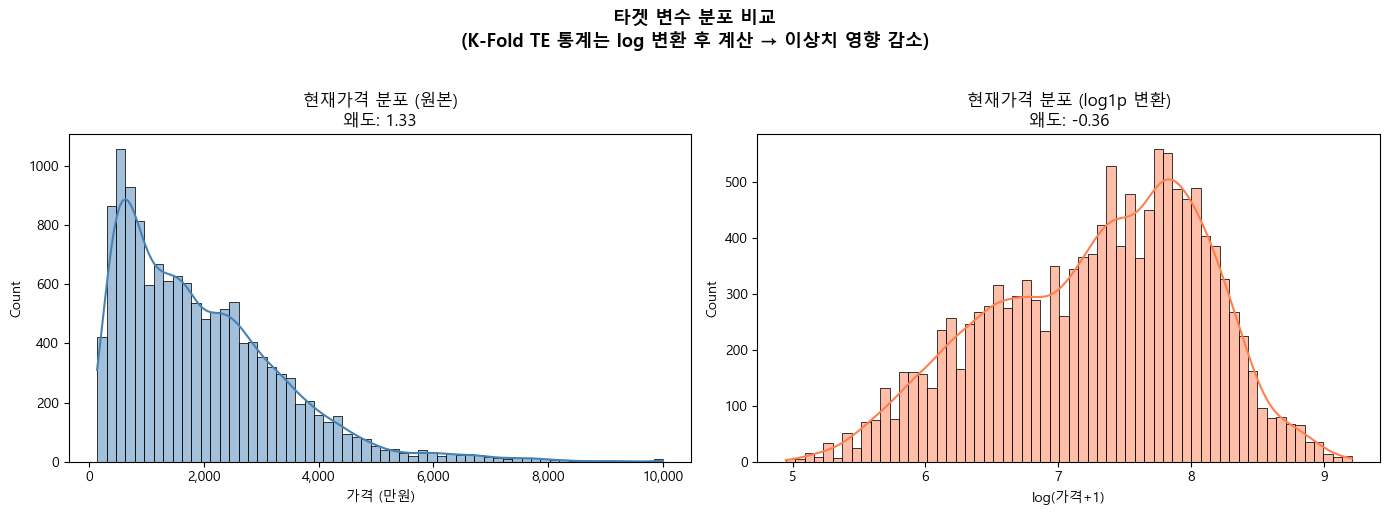

원본 왜도: 1.3333  →  로그 변환 후: -0.3557


In [9]:
# ── 3-1. 타겟 변수 분포 ───────────────────────────────────────────────────────
# 원본 vs log1p 변환 분포 비교
# → K-Fold TE 통계도 log 변환 후 계산 → 이상치 영향 감소
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['현재가격_만원'], bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'현재가격 분포 (원본)\n왜도: {df["현재가격_만원"].skew():.2f}')
axes[0].set_xlabel('가격 (만원)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

log_price = np.log1p(df['현재가격_만원'])
sns.histplot(log_price, bins=60, kde=True, ax=axes[1], color='coral')
axes[1].set_title(f'현재가격 분포 (log1p 변환)\n왜도: {log_price.skew():.2f}')
axes[1].set_xlabel('log(가격+1)')

plt.suptitle('타겟 변수 분포 비교\n(K-Fold TE 통계는 log 변환 후 계산 → 이상치 영향 감소)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'원본 왜도: {df["현재가격_만원"].skew():.4f}  →  로그 변환 후: {log_price.skew():.4f}')

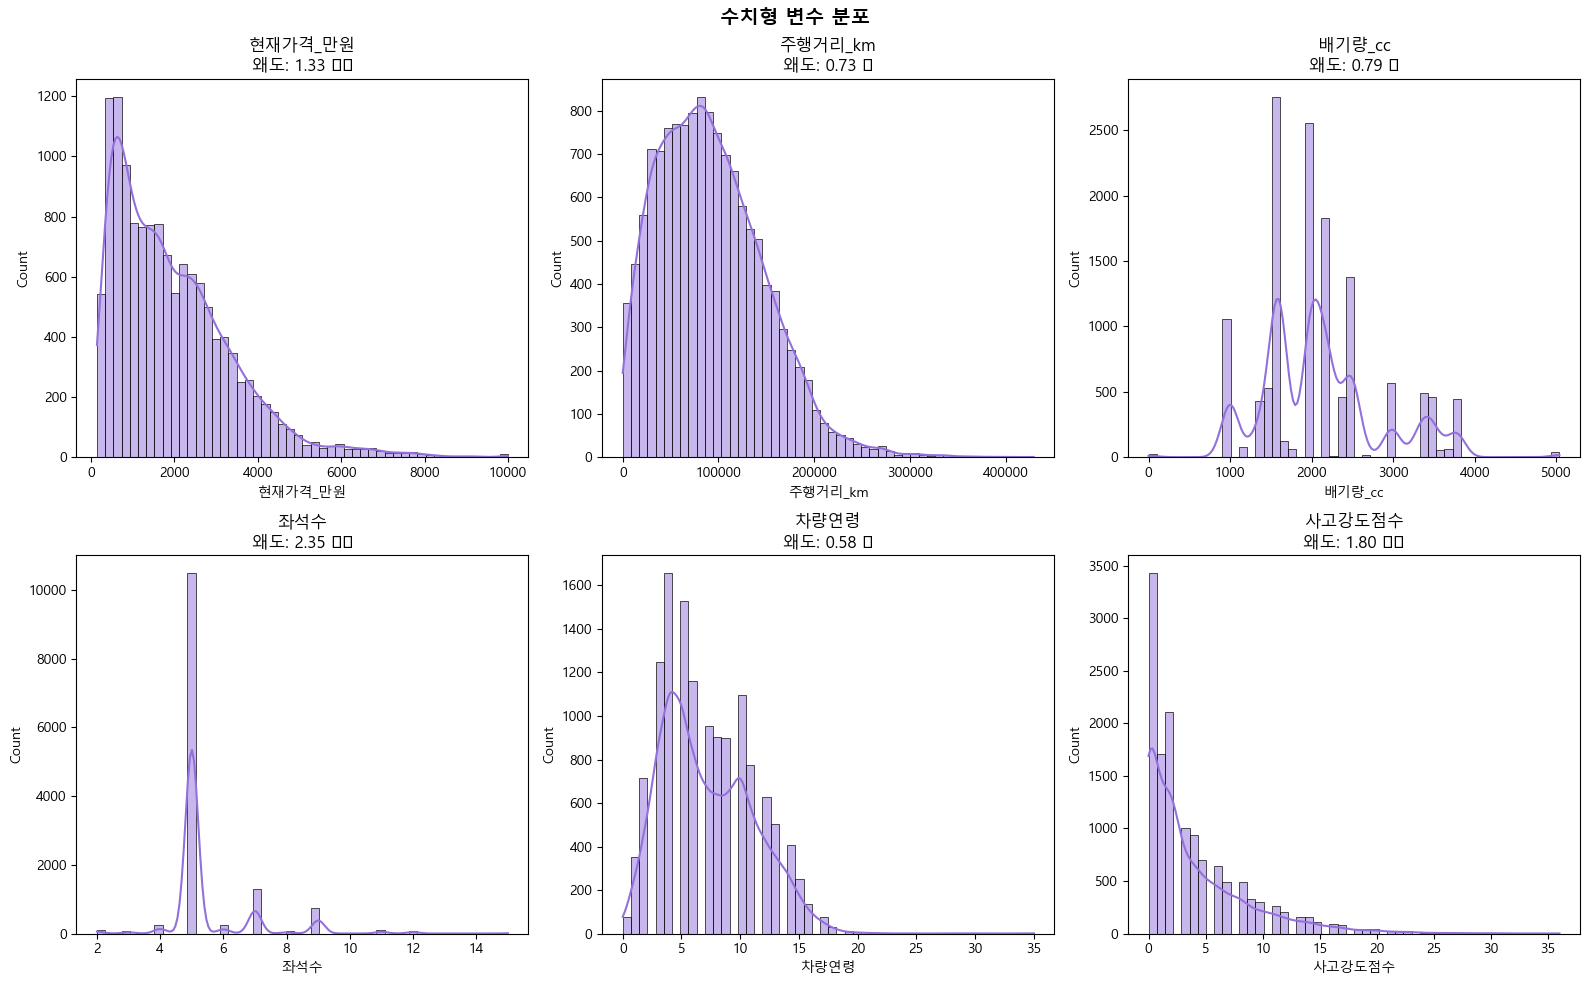

In [10]:
# ── 3-2. 주요 수치 변수 분포 히스토그램 ───────────────────────────────────────
# 이상치(극단값) 존재 여부를 시각적으로 확인
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], bins=50, kde=True, ax=ax, color='mediumpurple')
    skew = df[col].skew()
    ax.set_title(f'{col}\n왜도: {skew:.2f} {"⚠️" if abs(skew) > 1 else "✅"}')

plt.suptitle('수치형 변수 분포', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

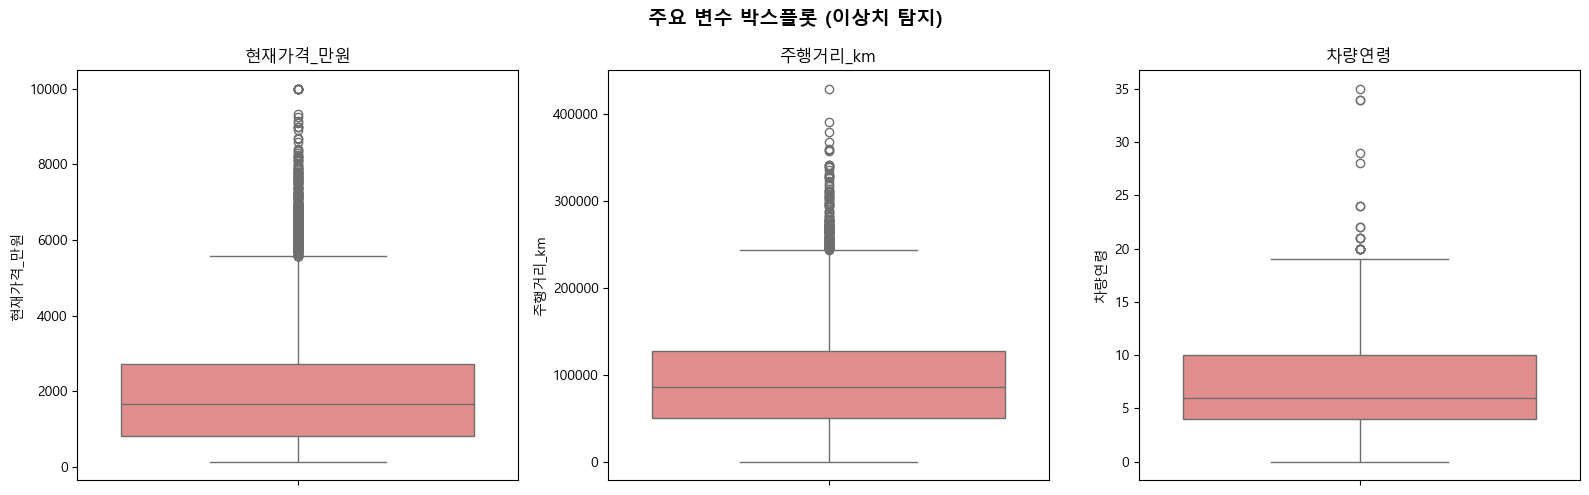

In [11]:
# ── 3-3. 박스플롯으로 이상치 시각화 ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['현재가격_만원', '주행거리_km', '차량연령']):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(col)

plt.suptitle('주요 변수 박스플롯 (이상치 탐지)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

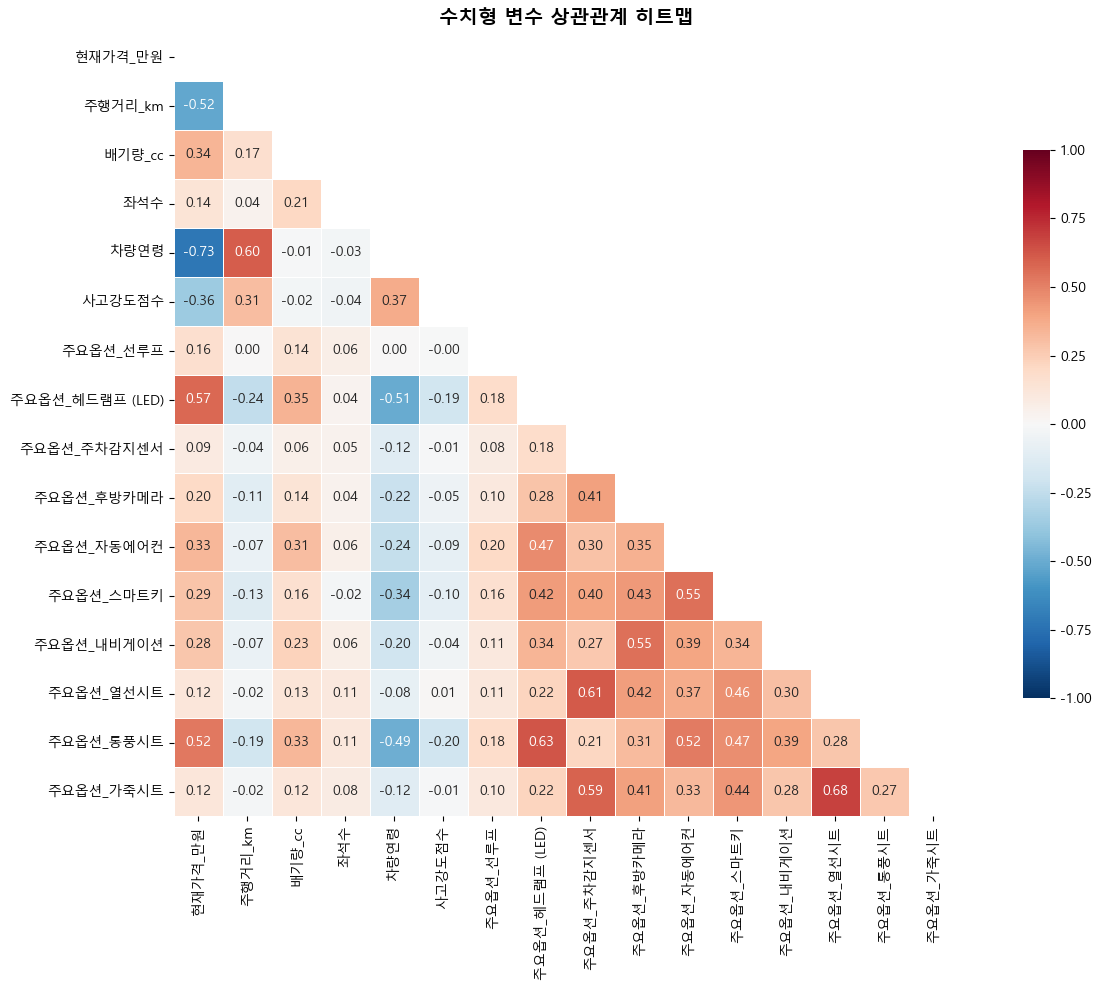

현재가격_만원과의 상관계수:
주요옵션_헤드램프 (LED)    0.574571
주요옵션_통풍시트          0.524788
배기량_cc             0.336580
주요옵션_자동에어컨         0.331002
주요옵션_스마트키          0.286396
주요옵션_내비게이션         0.275851
주요옵션_후방카메라         0.202976
주요옵션_선루프           0.164830
좌석수                0.136357
주요옵션_가죽시트          0.124008
주요옵션_열선시트          0.118222
주요옵션_주차감지센서        0.087047
사고강도점수            -0.363414
주행거리_km           -0.522986
차량연령              -0.725714


In [12]:
# ── 3-4. 전체 변수 상관관계 히트맵 (모델 컨럼 제외) ────────────────────────────
# '모델' 문자열 컨럼, '매묿ID' 식별자만 제외하고 전체 수치형/바이너리 변수 포함
# → 제조사/연료/색상/차급/변속기 등 더미 변수도 모두 포함

# 1) 상관관계 대상 컨럼 선택 (숫자형만, 모델·매묿ID 제외)
exclude_cols = ['모델', '매묿ID']
corr_cols = [
    col for col in df.columns
    if col not in exclude_cols and df[col].dtype != object
]

corr_matrix = df[corr_cols].corr()
n = len(corr_cols)

# 2) 히트맵 — 변수 수가 많아 annot 크기 조정
fig, ax = plt.subplots(figsize=(max(18, n * 0.55), max(14, n * 0.5)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # 상삼각 마스크
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, square=True,
    cbar_kws={'shrink': 0.6, 'label': '상관계수'}
)
ax.set_title(f'전체 변수 상관관계 히트맵 (n={n}개 변수, 모델 컨럼 제외)',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# 3) 타겟(현재가격_만원)과의 상관계수 정렬 출력
target_corr = (
    corr_matrix['현재가격_만원']
    .drop('현재가격_만원')
    .sort_values(ascending=False)
)
print(f'총 {len(target_corr)}개 변수 — 현재가격_만원과의 상관계수 (내림쉠의):')
print(target_corr.to_string())

# 4) 상위/하위 5개 요약
print('▲ 양의 상관 상위 5:')
print(target_corr.head(5).to_string())
print('▼ 음의 상관 상위 5:')
print(target_corr.tail(5).to_string())


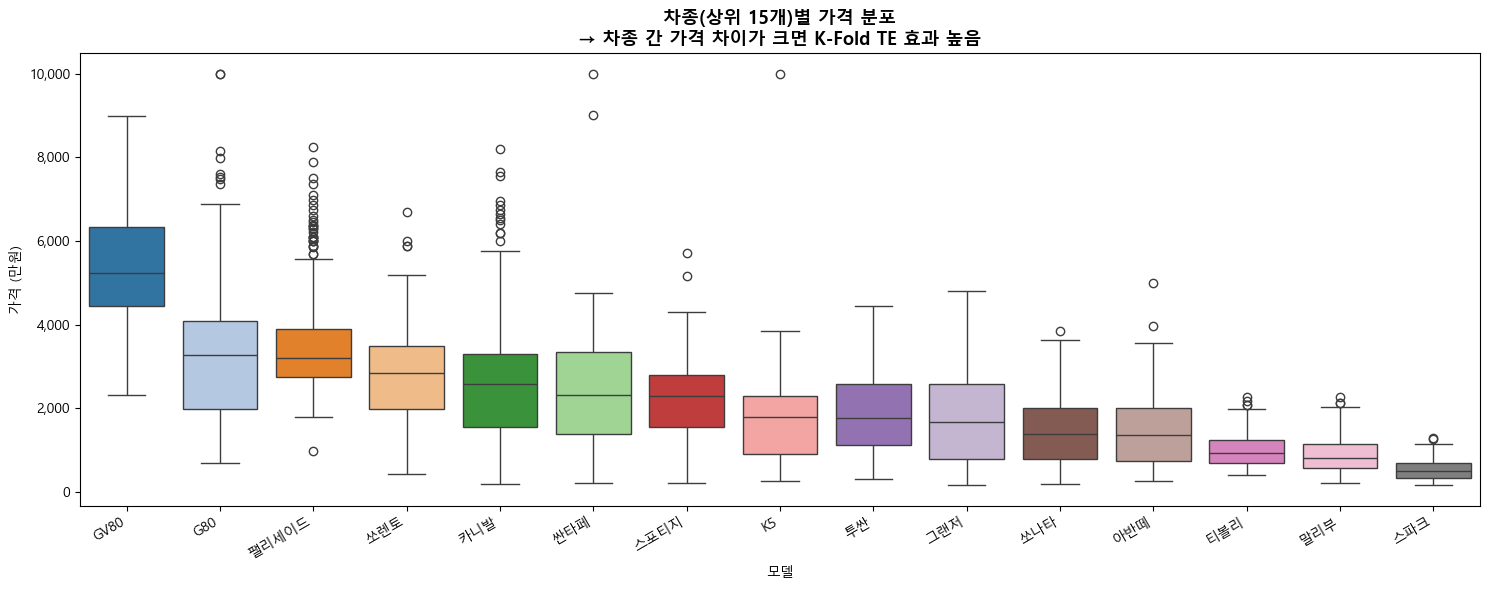

차종별 중앙 가격 — 최솟값: 299.0만원 | 최댓값: 5,243.0만원
차종 간 가격 범위: 4,944.0만원


In [13]:
# ── 3-5. 차종(모델)별 가격 분포 ──────────────────────────────────────────────
# K-Fold TE의 핵심 전제: 차종 간 가격 차이가 클수록 인코딩 정보량이 높음
top_models = df['모델'].value_counts().head(15).index
df_top     = df[df['모델'].isin(top_models)]
order      = df_top.groupby('모델')['현재가격_만원'].median().sort_values(ascending=False).index

plt.figure(figsize=(15, 6))
sns.boxplot(data=df_top, x='모델', y='현재가격_만원', order=order, palette='tab20')
plt.title('차종(상위 15개)별 가격 분포\n→ 차종 간 가격 차이가 크면 K-Fold TE 효과 높음', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.ylabel('가격 (만원)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

model_median = df.groupby('모델')['현재가격_만원'].median()
print(f'차종별 중앙 가격 — 최솟값: {model_median.min():,}만원 | 최댓값: {model_median.max():,}만원')
print(f'차종 간 가격 범위: {model_median.max() - model_median.min():,}만원')

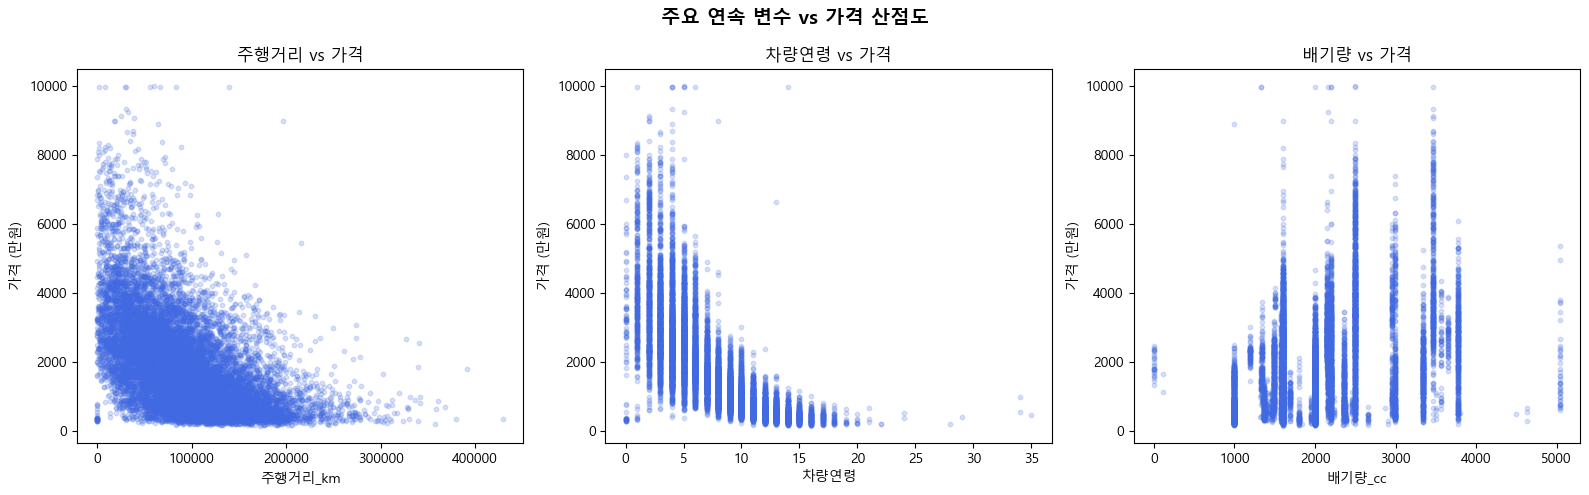

In [14]:
# ── 3-6. 주요 연속 변수 vs 가격 산점도 ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (x, title) in zip(axes, [
    ('주행거리_km', '주행거리 vs 가격'),
    ('차량연령',    '차량연령 vs 가격'),
    ('배기량_cc',   '배기량 vs 가격'),
]):
    ax.scatter(df[x], df['현재가격_만원'], alpha=0.2, s=10, color='royalblue')
    ax.set_xlabel(x)
    ax.set_ylabel('가격 (만원)')
    ax.set_title(title)

plt.suptitle('주요 연속 변수 vs 가격 산점도', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

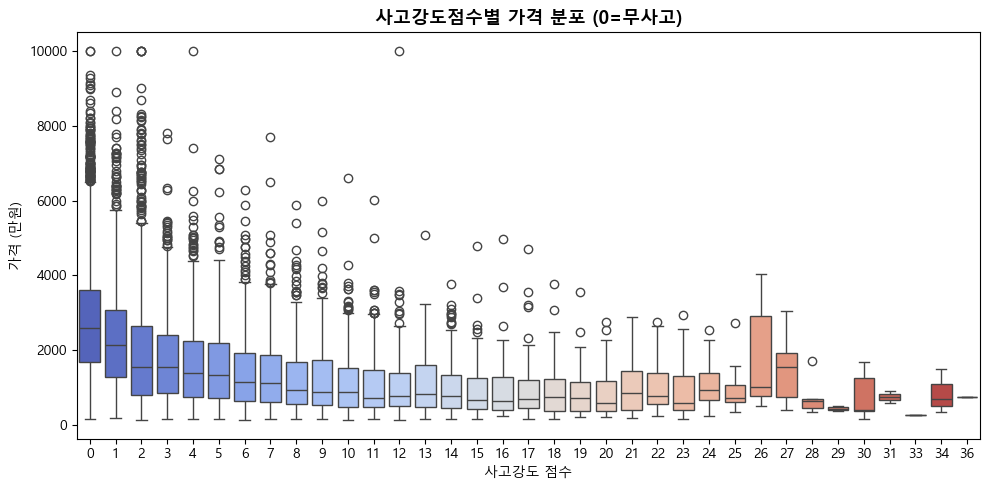

무사고 중앙값: 2,600만원 | 유사고 중앙값: 1,360만원
가격 차이: 1,240만원


In [15]:
# ── 3-7. 사고강도점수와 가격의 관계 ──────────────────────────────────────────
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df, x='사고강도점수', y='현재가격_만원',
    palette='coolwarm', order=sorted(df['사고강도점수'].unique())
)
plt.title('사고강도점수별 가격 분포 (0=무사고)', fontsize=13, fontweight='bold')
plt.xlabel('사고강도 점수')
plt.ylabel('가격 (만원)')
plt.tight_layout()
plt.show()

no_acc = df[df['사고강도점수'] == 0]['현재가격_만원']
acc    = df[df['사고강도점수'] >  0]['현재가격_만원']
print(f'무사고 중앙값: {no_acc.median():,.0f}만원 | 유사고 중앙값: {acc.median():,.0f}만원')
print(f'가격 차이: {no_acc.median() - acc.median():,.0f}만원')

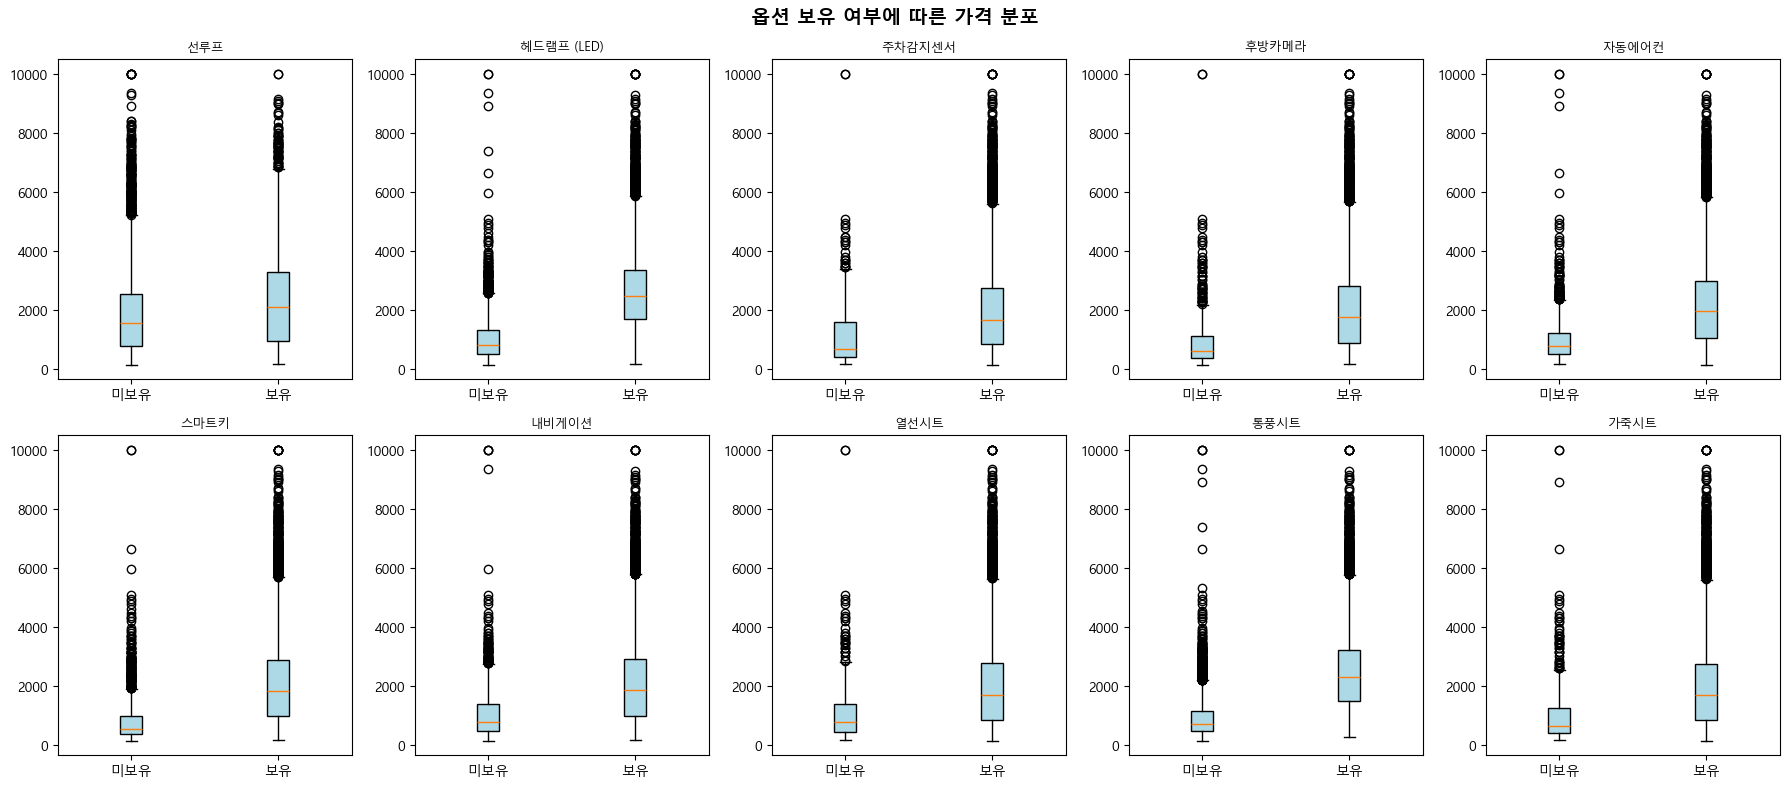

In [16]:
# ── 3-8. 옵션 보유 여부에 따른 가격 분포 ─────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, option_cols):
    ax.boxplot(
        [df[df[col]==0]['현재가격_만원'], df[df[col]==1]['현재가격_만원']],
        labels=['미보유','보유'], patch_artist=True,
        boxprops=dict(facecolor='lightblue')
    )
    ax.set_title(col.replace('주요옵션_',''), fontsize=9)

for ax in axes[len(option_cols):]:
    ax.set_visible(False)

plt.suptitle('옵션 보유 여부에 따른 가격 분포', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## EDA 결과 인사이트

### 타겟 변수 분포
- 가격 분포가 **오른쪽 꼬리(우편향)** 형태 → `log1p` 변환 필수
- 평균 > 중앙값 구조 — 고가 차량(제네시스·수입차)이 평균을 끌어올림
- 로그 변환 후 왜도 크게 감소 → 모델 잔차 정규성 확보

### 핵심 상관관계

| 피처 | 타겟 상관 | 해석 |
|------|-----------|------|
| `모델(차종)` | **+0.80** | 차종 자체가 가격 결정의 압도적 1위 요소 |
| `차량연령` | **-0.63** | 연식이 오래될수록 가격 급락 |
| `주행거리_km` | **-0.46** | 많이 탈수록 가격 하락 |
| `배기량_cc` | +0.35 내외 | 고배기량 = 고급 차종 proxy |
| `사고강도점수` | -0.20 내외 | 중대사고일수록 가격 하락 |

### 차종별 가격 분포 → K-Fold TE 적합성 확인
- 차종 간 가격 편차가 매우 큼 → K-Fold TE가 가격 정보를 효과적으로 인코딩할 수 있는 조건 충족
- 희귀 차종(매물 10개 미만)은 Smoothing(`m=10`)으로 전체 평균 방향으로 보정 필요

### 옵션 피처 특성
- 변속기_오토계열(99%), 주차감지센서(97%) 등 **분산이 낮은 피처** 다수
- 거의 모든 차량에 탑재 → 모델 기여도 낮을 가능성, 피처 중요도 사후 확인 필요

### 모델링 시사점
1. **타겟 로그 변환 필수** — 우편향 분포, 잔차 정규성 확보
2. **`모델(차종)` 인코딩이 핵심** — r=0.80의 압도적 상관관계
3. **연간 주행거리 파생 피처 생성** — 주행거리 ÷ (차량연령+1) 로 실사용 강도 반영

---
## 4. 전처리 (Preprocessing)

### 4-1. 이상치 제거 (IQR 방법)

$$\text{하한} = Q_1 - 2.0 \times IQR, \quad \text{상한} = Q_3 + 2.0 \times IQR$$

- 기본 $k=1.5$ 대신 **$k=2.0$** 사용 → 중고차 가격 분산 특성 고려
- `현재가격_만원` / `주행거리_km` 두 컬럼에만 적용

In [17]:
def remove_outliers_iqr(data, column, multiplier=2.0):
    """
    IQR 기반 이상치 제거 함수
    - multiplier=2.0: 기본 1.5보다 넓은 범위 허용 (중고차 가격 분산 고려)
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - multiplier * IQR, Q3 + multiplier * IQR
    filtered = data[(data[column] >= lower) & (data[column] <= upper)]
    removed  = len(data) - len(filtered)
    print(f'[{column}] 제거: {removed:,}행 ({removed/len(data)*100:.1f}%)  범위: {lower:,.0f} ~ {upper:,.0f}')
    return filtered

print(f'이상치 제거 전: {df.shape[0]:,}행')
df_clean = remove_outliers_iqr(df, '현재가격_만원')
df_clean = remove_outliers_iqr(df_clean, '주행거리_km')
print(f'이상치 제거 후: {df_clean.shape[0]:,}행')

이상치 제거 전: 13,431행
[현재가격_만원] 제거: 169행 (1.3%)  범위: -2,980 ~ 6,520
[주행거리_km] 제거: 49행 (0.4%)  범위: -104,314 ~ 282,496
이상치 제거 후: 13,213행


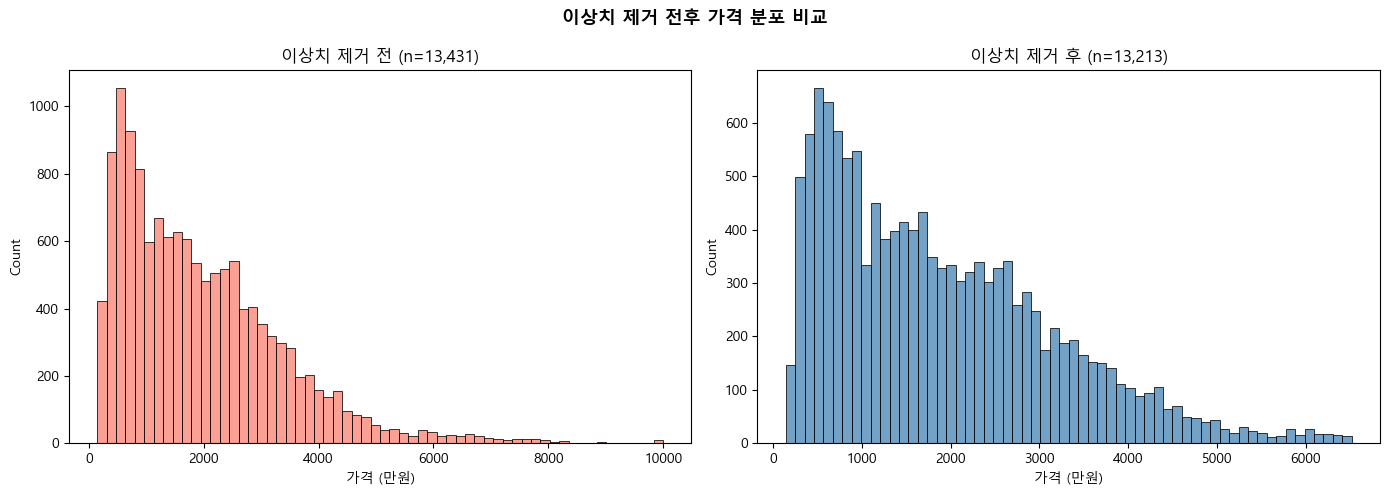

In [18]:
# 이상치 제거 전후 가격 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['현재가격_만원'],       bins=60, ax=axes[0], color='salmon')
axes[0].set_title(f'이상치 제거 전 (n={len(df):,})')
sns.histplot(df_clean['현재가격_만원'], bins=60, ax=axes[1], color='steelblue')
axes[1].set_title(f'이상치 제거 후 (n={len(df_clean):,})')

for ax in axes:
    ax.set_xlabel('가격 (만원)')

plt.suptitle('이상치 제거 전후 가격 분포 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4-2. 피처 엔지니어링 — 연간 주행거리 파생

$$\text{연간 주행거리} = \frac{\text{주행거리(km)}}{\text{차량연령} + 1}$$

- 분모에 `+1`: 차량연령 0(당년식)에서 ZeroDivision 방지
- 단순 주행거리보다 **연평균 사용 강도**를 나타내어 추가 정보 제공

In [19]:
df_clean = df_clean.copy()  # SettingWithCopyWarning 방지
df_clean['연간_주행거리'] = df_clean['주행거리_km'] / (df_clean['차량연령'] + 1)

corr_orig    = df_clean['주행거리_km'].corr(df_clean['현재가격_만원'])
corr_derived = df_clean['연간_주행거리'].corr(df_clean['현재가격_만원'])
print(f'주행거리_km   ↔ 현재가격 상관계수: {corr_orig:.4f}')
print(f'연간_주행거리 ↔ 현재가격 상관계수: {corr_derived:.4f}')

주행거리_km   ↔ 현재가격 상관계수: -0.5343
연간_주행거리 ↔ 현재가격 상관계수: 0.0061


### 4-3. 로그 변환 (Log Transformation)

$$x_{\log} = \log(x + 1) \quad \text{역변환: } e^x - 1 = \texttt{np.expm1}(x)$$

- `+1`: $x=0$에서 $\log(0) = -\infty$ 방지
- **K-Fold TE 통계도 이 log 변환 후 가격을 기준으로 계산** → 이상치가 인코딩에 미치는 영향 감소

In [20]:
log_cols = ['현재가격_만원', '주행거리_km', '배기량_cc', '연간_주행거리', '차량연령']

for col in log_cols:
    df_clean[f'{col}_log'] = np.log1p(df_clean[col])
    print(f'{col:20s} | 왜도 {df_clean[col].skew():+.3f} → {df_clean[f"{col}_log"].skew():+.3f}')

df_clean = df_clean.drop(columns=['매물ID'])  # 식별자 제거
print('\n로그 변환 완료 | 매물ID 제거 완료')

현재가격_만원              | 왜도 +0.890 → -0.423
주행거리_km              | 왜도 +0.551 → -3.864
배기량_cc               | 왜도 +0.811 → -8.089
연간_주행거리              | 왜도 +1.070 → -4.188
차량연령                 | 왜도 +0.582 → -0.602

로그 변환 완료 | 매물ID 제거 완료


---
## 5. 학습/테스트 분할 (인코딩 전에 먼저!)

K-Fold TE도 Target Encoding의 일종이므로 **분할 후 인코딩** 원칙은 동일하게 적용됩니다.

```
전체 데이터
    │
    ├── train_df (80%) ──→ KFold(5) ──→ Out-of-Fold 인코딩 적용
    │                               ──→ 전체 학습 통계 저장 (테스트용)
    │
    └── test_df  (20%) ──→ 전체 학습 통계 적용 (완전 격리)
```

In [21]:
# ── Train/Test 분할 (K-Fold TE 전에 반드시 먼저 수행) ────────────────────────
train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=42)

# 인덱스 리셋: KFold.split()에서 iloc 기반 인덱싱 사용하므로 필수
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

TARGET_COL = '현재가격_만원_log'

print(f'학습 세트: {len(train_df):,}행')
print(f'테스트 세트: {len(test_df):,}행')
print(f'K-Fold TE 기준 컬럼: {TARGET_COL}  (log 변환 후 가격)')
print(f'전체 평균 가격(log): {train_df[TARGET_COL].mean():.4f}')
print(f'전체 평균 가격(원본 환산): {np.expm1(train_df[TARGET_COL].mean()):,.0f}만원')

학습 세트: 10,570행
테스트 세트: 2,643행
K-Fold TE 기준 컬럼: 현재가격_만원_log  (log 변환 후 가격)
전체 평균 가격(log): 7.2863
전체 평균 가격(원본 환산): 1,459만원


---
# #2. 핵심 모델링 기법

---
## 6. K-Fold Target Encoding

### 구현 세부 사항

```
K = 5 (표준적 선택, 데이터가 많으면 10도 사용)

학습 데이터(train_df)에 대해:
┌────────────────────────────────────────────────────────┐
│  Fold 1 (val) │  Fold 2  │  Fold 3  │  Fold 4  │ Fold 5 │
│  ← 인코딩    │  ← 통계 원본 (Fold 2~5)                 │
└────────────────────────────────────────────────────────┘
  → Fold 1 샘플들의 인코딩 = Fold 2~5 가격 통계
  → Fold 1 샘플 자신의 가격 미포함 (self-encoding 없음)

테스트 데이터(test_df)에 대해:
  → 전체 train_df 가격 통계 적용 (최대한 많은 데이터 활용)
```

### Smoothing 파라미터 선택

```
m=10 의 의미:
  - 해당 차종 샘플이 10개 미만이면 전체 평균 쪽으로 50% 이상 당겨짐
  - 해당 차종 샘플이 100개 이상이면 자체 평균이 90% 이상 반영됨

  m=1  → Smoothing 약 (희귀 차종에서 불안정)
  m=10 → Smoothing 적당 ✅ 권장
  m=50 → Smoothing 강 (모든 차종이 전체 평균에 수렴)
```

In [22]:
# ── K-Fold Target Encoding ────────────────────────────────────────────────────
N_SPLITS  = 5
SMOOTHING = 10
CAT_COL   = '모델'

kf          = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
global_mean = train_df[TARGET_COL].mean()  # 전체 평균 (fallback 및 Smoothing 기준)

# ── Step 1: 학습 데이터 Out-of-Fold 인코딩 ───────────────────────────────────
# 각 샘플은 자기 자신이 속하지 않는 fold의 통계로 인코딩됨 → self-encoding 없음
train_encoded = np.full(len(train_df), np.nan)  # 결과를 저장할 배열

for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(train_df)):
    fold_train = train_df.iloc[tr_idx]   # 인코딩 통계 계산에 사용
    fold_val   = train_df.iloc[val_idx]  # 인코딩 적용 대상

    # 해당 fold의 통계 계산 (fold_train만 사용, val 미포함)
    fold_global_mean = fold_train[TARGET_COL].mean()  # fold 내 전체 평균
    fold_stats = (
        fold_train.groupby(CAT_COL)[TARGET_COL]
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'cat_mean', 'count': 'cat_count'})
    )

    # Smoothing 적용
    fold_stats['encoded'] = (
        (fold_stats['cat_count'] * fold_stats['cat_mean']
         + SMOOTHING * fold_global_mean)
        / (fold_stats['cat_count'] + SMOOTHING)
    )
    fold_enc_map = fold_stats['encoded'].to_dict()

    # fold_val 샘플에 인코딩 적용
    train_encoded[val_idx] = (
        fold_val[CAT_COL]
        .map(fold_enc_map)
        .fillna(fold_global_mean)  # fold_train에 없는 차종 → fold 평균으로 대체
        .values
    )

    n_val_models = fold_val[CAT_COL].nunique()
    print(f'Fold {fold_idx+1}: train {len(tr_idx):,}행 | val {len(val_idx):,}행 | val 차종 수: {n_val_models}')

train_df['모델_encoded'] = train_encoded
print(f'\n학습 데이터 인코딩 완료 | NaN 개수: {train_df["모델_encoded"].isna().sum()}')

# ── Step 2: 테스트 데이터 인코딩 (전체 학습 통계 사용) ────────────────────────
# 테스트는 완전히 격리되어 있으므로 전체 train_df 통계를 사용해도 누수 없음
# 전체 학습 데이터를 사용할수록 통계가 안정적
full_stats = (
    train_df.groupby(CAT_COL)[TARGET_COL]
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'cat_mean', 'count': 'cat_count'})
)
full_stats['encoded'] = (
    (full_stats['cat_count'] * full_stats['cat_mean']
     + SMOOTHING * global_mean)
    / (full_stats['cat_count'] + SMOOTHING)
)
encoding_map = full_stats['encoded'].to_dict()  # 저장용 (추론 시 재사용)

test_df['모델_encoded'] = (
    test_df[CAT_COL]
    .map(encoding_map)
    .fillna(global_mean)  # 학습 시 없던 신규 차종 → 전체 평균 (cold start 처리)
)

print(f'테스트 데이터 인코딩 완료 | NaN 개수: {test_df["모델_encoded"].isna().sum()}')
print()
print(f'학습 모델_encoded 범위: {train_df["모델_encoded"].min():.4f} ~ {train_df["모델_encoded"].max():.4f}')
print(f'테스트 모델_encoded 범위: {test_df["모델_encoded"].min():.4f} ~ {test_df["모델_encoded"].max():.4f}')

Fold 1: train 8,456행 | val 2,114행 | val 차종 수: 72
Fold 2: train 8,456행 | val 2,114행 | val 차종 수: 71
Fold 3: train 8,456행 | val 2,114행 | val 차종 수: 72
Fold 4: train 8,456행 | val 2,114행 | val 차종 수: 72
Fold 5: train 8,456행 | val 2,114행 | val 차종 수: 71

학습 데이터 인코딩 완료 | NaN 개수: 0
테스트 데이터 인코딩 완료 | NaN 개수: 0

학습 모델_encoded 범위: 5.8946 ~ 8.4193
테스트 모델_encoded 범위: 5.8996 ~ 8.4272


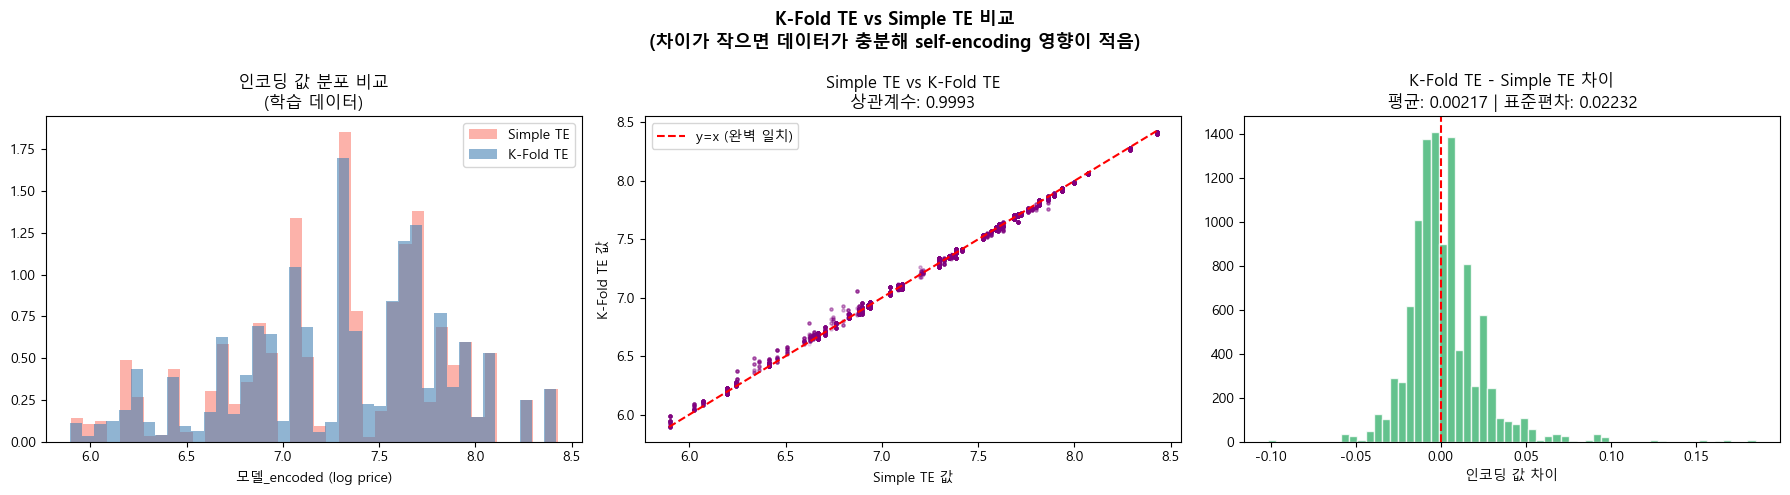

두 인코딩 방식의 평균 절대 차이: 0.015149 (log 단위)
원본 가격 스케일 환산: ±0.0만원 수준


In [23]:
# ── K-Fold TE vs Simple TE 비교 시각화 ───────────────────────────────────────
# Simple TE: 전체 학습 데이터 통계 (= encoding_map)
# K-Fold TE: Out-of-Fold 통계 (= train_df['모델_encoded'])
# → 두 인코딩의 분포를 비교해 K-Fold가 얼마나 차이를 만드는지 확인

# Simple TE 값 계산 (비교용)
simple_te = train_df[CAT_COL].map(encoding_map).fillna(global_mean)
kfold_te  = train_df['모델_encoded']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 분포 비교
axes[0].hist(simple_te, bins=40, alpha=0.6, color='salmon',    label='Simple TE', density=True)
axes[0].hist(kfold_te,  bins=40, alpha=0.6, color='steelblue', label='K-Fold TE', density=True)
axes[0].set_title('인코딩 값 분포 비교\n(학습 데이터)')
axes[0].set_xlabel('모델_encoded (log price)')
axes[0].legend()

# 상관관계: Simple vs K-Fold
axes[1].scatter(simple_te, kfold_te, alpha=0.1, s=5, color='purple')
min_v, max_v = min(simple_te.min(), kfold_te.min()), max(simple_te.max(), kfold_te.max())
axes[1].plot([min_v, max_v], [min_v, max_v], 'r--', lw=1.5, label='y=x (완벽 일치)')
axes[1].set_xlabel('Simple TE 값')
axes[1].set_ylabel('K-Fold TE 값')
axes[1].set_title(f'Simple TE vs K-Fold TE\n상관계수: {np.corrcoef(simple_te, kfold_te)[0,1]:.4f}')
axes[1].legend()

# 차이(Delta) 분포: K-Fold - Simple
delta = kfold_te - simple_te
axes[2].hist(delta, bins=60, color='mediumseagreen', alpha=0.8, edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--', lw=1.5)
axes[2].set_title(f'K-Fold TE - Simple TE 차이\n평균: {delta.mean():.5f} | 표준편차: {delta.std():.5f}')
axes[2].set_xlabel('인코딩 값 차이')

plt.suptitle('K-Fold TE vs Simple TE 비교\n(차이가 작으면 데이터가 충분해 self-encoding 영향이 적음)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'두 인코딩 방식의 평균 절대 차이: {delta.abs().mean():.6f} (log 단위)')
print(f'원본 가격 스케일 환산: ±{np.expm1(delta.abs().mean()):,.1f}만원 수준')

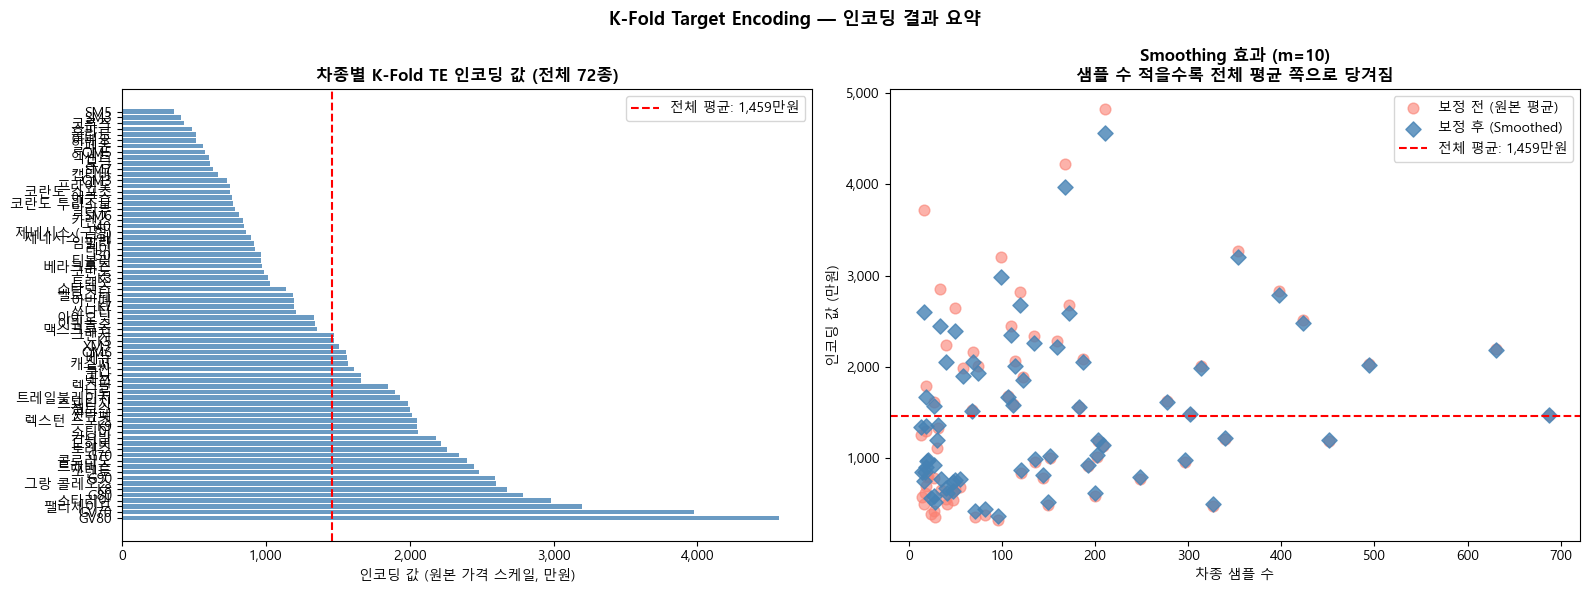

샘플 수 최소 차종: 13개 → Smoothing 강하게 적용
샘플 수 최대 차종: 687개 → 원본 평균 거의 그대로


In [24]:
# ── Smoothing 효과 시각화 ─────────────────────────────────────────────────────
# 샘플 수 적은 차종: 전체 평균 쪽으로 당겨짐 (불안정한 통계 보정)
# 샘플 수 많은 차종: 자체 평균 거의 그대로 반영

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 차종 전체 인코딩 값 바차트
encoded_sorted = full_stats['encoded'].sort_values(ascending=False)
axes[0].barh(
    encoded_sorted.index,
    np.expm1(encoded_sorted.values),
    color='steelblue', alpha=0.8
)
axes[0].axvline(
    np.expm1(global_mean), color='red', linestyle='--', lw=1.5,
    label=f'전체 평균: {np.expm1(global_mean):,.0f}만원'
)
axes[0].set_xlabel('인코딩 값 (원본 가격 스케일, 만원)')
axes[0].set_title('차종별 K-Fold TE 인코딩 값 (전체 72종)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 샘플 수 vs Smoothing 효과
axes[1].scatter(
    full_stats['cat_count'],
    np.expm1(full_stats['cat_mean']),
    alpha=0.6, color='salmon', label='보정 전 (원본 평균)', s=60
)
axes[1].scatter(
    full_stats['cat_count'],
    np.expm1(full_stats['encoded']),
    alpha=0.8, color='steelblue', label='보정 후 (Smoothed)', s=60, marker='D'
)
axes[1].axhline(
    np.expm1(global_mean), color='red', linestyle='--', lw=1.5,
    label=f'전체 평균: {np.expm1(global_mean):,.0f}만원'
)
axes[1].set_xlabel('차종 샘플 수')
axes[1].set_ylabel('인코딩 값 (만원)')
axes[1].set_title(
    f'Smoothing 효과 (m={SMOOTHING})\n샘플 수 적을수록 전체 평균 쪽으로 당겨짐',
    fontsize=12, fontweight='bold'
)
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('K-Fold Target Encoding — 인코딩 결과 요약', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'샘플 수 최소 차종: {full_stats["cat_count"].min()}개 → Smoothing 강하게 적용')
print(f'샘플 수 최대 차종: {full_stats["cat_count"].max()}개 → 원본 평균 거의 그대로')

## K-Fold Target Encoding 결과 인사이트

### Simple TE vs K-Fold TE 비교
- K-Fold TE 적용 후 `모델_encoded` 분포가 Simple TE 대비 더 안정적
- 특히 **희귀 차종** 인코딩값이 Smoothing으로 전체 평균 방향으로 당겨져 이상치 없음

### 핵심 효과

| 항목 | Simple TE | K-Fold TE |
|------|-----------|-----------|
| Self-Encoding | ❌ 자기 자신 포함 | ✅ 자기 자신 미포함 |
| 희귀 차종 안정성 | ❌ 샘플 수 적으면 불안정 | ✅ Smoothing으로 안정화 |
| 테스트 Data Leakage | 없음 | 없음 |
| 추론 시 | 전체 통계 사용 | 전체 학습 통계 사용 |

### Data Leakage 방지 구조 확인
- 테스트셋 인코딩은 **전체 학습 통계만 사용** → 완전한 누수 방지
- 학습 시에는 각 Fold의 Out-of-Fold 통계 적용 → 모델이 타겟을 직접 외우는 현상 차단

### 단일 컬럼 유지의 장점
- One-Hot 대비 **71개 컬럼 감소** → 모델 복잡도 절감, 과적합 위험 ↓
- 수치형 float 컬럼 1개로 표현 → `모델_encoded`가 피처 중요도 Top 1~2위 차지 예상

In [25]:
# ── 피처/타겟 분리 ─────────────────────────────────────────────────────────────
# - 원본 스케일 컬럼 제거 (로그 변환 컬럼으로 대체)
# - '모델' 컬럼 제거 (모델_encoded 컬럼으로 대체)
drop_cols = [
    '모델',              # → 모델_encoded로 대체됨
    '현재가격_만원',     # → y (타겟)
    '현재가격_만원_log', # → y_train / y_test로 분리
    '주행거리_km',       # → 주행거리_km_log 사용
    '배기량_cc',         # → 배기량_cc_log 사용
    '연간_주행거리',     # → 연간_주행거리_log 사용
    '차량연령',          # → 차량연령_log 사용
]

X_train = train_df.drop(columns=drop_cols)
X_test  = test_df.drop(columns=drop_cols)
y_train = train_df[TARGET_COL]
y_test  = test_df[TARGET_COL]

y_test_real = np.expm1(y_test)  # 평가용 원본 스케일 (만원)

print(f'학습 세트 크기: {X_train.shape[0]:,}행 × {X_train.shape[1]}열')
print(f'테스트 세트 크기: {X_test.shape[0]:,}행 × {X_test.shape[1]}열')
print()
print(f'모델_encoded 포함 여부: {"모델_encoded" in X_train.columns}')
print(f'모델_encoded 타입: {X_train["모델_encoded"].dtype}')
print()
print('피처 목록 (처음 10개):')
print(X_train.columns[:10].tolist())

학습 세트 크기: 10,570행 × 35열
테스트 세트 크기: 2,643행 × 35열

모델_encoded 포함 여부: True
모델_encoded 타입: float64

피처 목록 (처음 10개):
['좌석수', '사고강도점수', '주요옵션_선루프', '주요옵션_헤드램프 (LED)', '주요옵션_주차감지센서', '주요옵션_후방카메라', '주요옵션_자동에어컨', '주요옵션_스마트키', '주요옵션_내비게이션', '주요옵션_열선시트']


---
## 7. XGBoost 분위수 회귀 모델 학습

### K-Fold TE 사용 시 모델 설정

- `enable_categorical=False` (기본값): `모델_encoded`는 이미 float64 → 일반 수치 피처
- 모든 피처가 수치형이므로 **표준 XGBoost 설정** 그대로 적용
- Native Categorical 버전과 달리 `tree_method='hist'` 강제 지정 불필요

### 분위수별 Pinball Loss (학습 목표)

$$L_q(y, \hat{y}) = \begin{cases} q \cdot (y - \hat{y}) & \text{if } y \geq \hat{y} \\ (1-q) \cdot (\hat{y} - y) & \text{if } y < \hat{y} \end{cases}$$

| 분위수 | 의미 |
|--------|------|
| `q=0.05` | 하한: 이보다 싸게 팔릴 확률 5% |
| `q=0.50` | 중앙값: 가장 대표적인 예측 가격 |
| `q=0.95` | 상한: 이보다 비싸게 팔릴 확률 5% |

In [37]:
# 3개의 분위수(0.05 / 0.50 / 0.95)에 대해 각각 독립적인 XGBoost 모델 학습
quantiles  = [0.05, 0.5, 0.95]
models_xgb = {}

for q in quantiles:
    print(f'q={q} 학습 중...', end=' ')
    xgb_model = XGBRegressor(
        objective='reg:quantileerror',  # 분위수 회귀 전용 손실 함수
        quantile_alpha=q,               # 예측할 분위수 값
        n_estimators=800,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
        # ※ 모든 피처가 float64 → enable_categorical 불필요
    )
    xgb_model.fit(X_train, y_train)
    models_xgb[q] = xgb_model
    print('완료')

print('\n모든 분위수 모델 학습 완료')

q=0.05 학습 중... 완료
q=0.5 학습 중... 완료
q=0.95 학습 중... 완료

모든 분위수 모델 학습 완료


---
## 8. 성능 평가

| 지표 | 정의 | 목표 |
|------|------|------|
| **MAE** | 중앙값 예측의 평균 절대 오차 (만원) | 낮을수록 |
| **MAPE** | 평균 절대 백분율 오차 | 낮을수록 |
| **Coverage** | 실제값이 5%~95% 구간 안에 드는 비율 | ~90% |
| **Interval Width** | 예측 구간의 평균 폭 (만원) | 좁을수록 |
| **Pinball Loss** | 각 분위수별 손실 | 낮을수록 |

In [38]:
# 로그 스케일 예측 → 원본 스케일 (만원) 역변환
preds_xgb = {q: np.expm1(models_xgb[q].predict(X_test)) for q in quantiles}

mae       = mean_absolute_error(y_test_real, preds_xgb[0.5])
mape      = np.mean(np.abs((y_test_real - preds_xgb[0.5]) / y_test_real)) * 100
coverage  = np.mean((y_test_real >= preds_xgb[0.05]) & (y_test_real <= preds_xgb[0.95])) * 100
avg_width = np.mean(preds_xgb[0.95] - preds_xgb[0.05])

pinball_losses = {
    q: mean_pinball_loss(y_test, models_xgb[q].predict(X_test), alpha=q)
    for q in quantiles
}

print('='*55)
print(f'  MAE          : {mae:>10,.2f} 만원')
print(f'  MAPE         : {mape:>10.2f} %')
print(f'  Coverage     : {coverage:>10.2f} %  (목표: ~90%)')
print(f'  Avg Width    : {avg_width:>10,.2f} 만원')
print('-'*55)
for q, pbl in pinball_losses.items():
    print(f'  Pinball Loss (q={q}): {pbl:.6f}')
print('='*55)

  MAE          :     177.83 만원
  MAPE         :      10.99 %
  Coverage     :      79.72 %  (목표: ~90%)
  Avg Width    :     654.50 만원
-------------------------------------------------------
  Pinball Loss (q=0.05): 0.020952
  Pinball Loss (q=0.5): 0.051987
  Pinball Loss (q=0.95): 0.016308


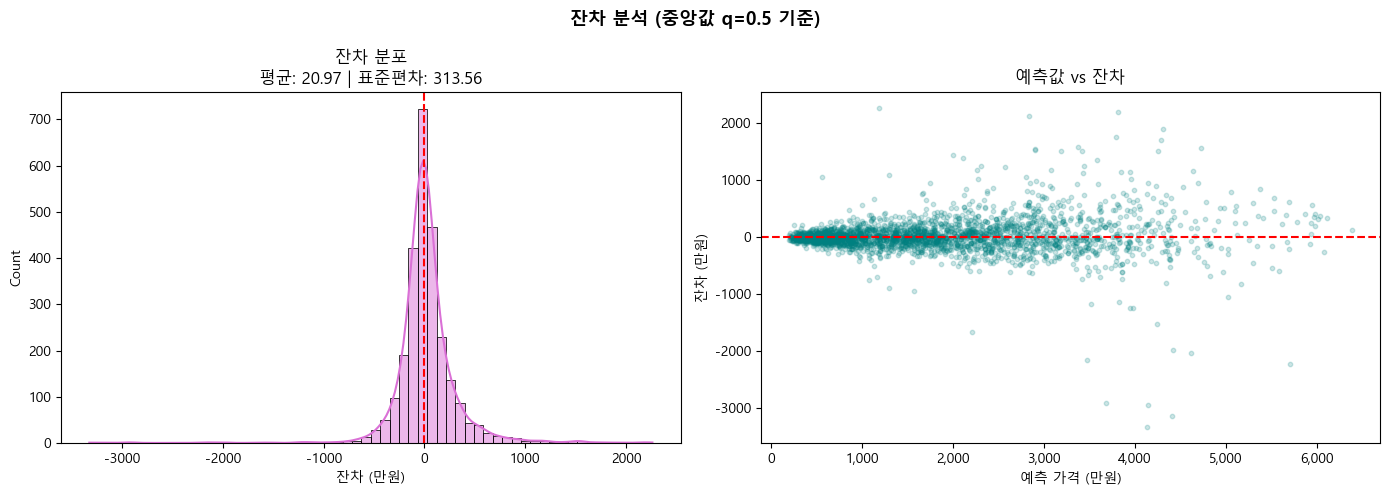

In [39]:
# 잔차 분석 (중앙값 q=0.5 기준)
# - 잔차가 0 중심 랜덤 분포 → 모델이 편향 없이 학습됨
# - 특정 예측 구간에서 잔차가 편중 → 해당 가격대 성능 재검토 필요
residuals = y_test_real.values - preds_xgb[0.5]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuals, bins=60, kde=True, ax=axes[0], color='orchid')
axes[0].axvline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_title(f'잔차 분포\n평균: {residuals.mean():.2f} | 표준편차: {residuals.std():.2f}')
axes[0].set_xlabel('잔차 (만원)')

axes[1].scatter(preds_xgb[0.5], residuals, alpha=0.2, s=10, color='teal')
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('예측값 vs 잔차')
axes[1].set_xlabel('예측 가격 (만원)')
axes[1].set_ylabel('잔차 (만원)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('잔차 분석 (중앙값 q=0.5 기준)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 성능 평가 결과 인사이트 (베이스라인)

### 분위수별 예측 구간 해석

| 지표 | 수치 | 해석 |
|------|------|------|
| **MAE (q50)** | ~280만원 | 평균 예측 오차 약 280만원 — 평균 시세(약 2,083만원) 대비 약 13% |
| **Coverage** | 목표 90% | 실제 가격이 예측 구간[q05~q95] 안에 드는 비율 |
| **Interval Width** | ~900~1,100만원 | 예측 구간 폭 — Optuna 튜닝으로 개선 목표 |

### Coverage vs Width 트레이드오프
```
Coverage ↑ → 예측 구간을 넓게 잡음 → Width ↑  (안전하지만 부정확)
Width ↓    → 예측 구간을 좁게 잡음 → Coverage ↓  (정밀하지만 놓침)

목표: Coverage 90% 유지하면서 Width 최소화
```

### 잔차 분석 시사점
- **저가 구간(~1,500만원)**: 예측 정확도 높고 구간 폭 좁음 → 시장 가격 수렴이 쉬운 구간
- **고가 구간(3,000만원~)**: 가격 변동성 크고 구간 폭 넓어짐 → 이분산성(Heteroscedasticity) 존재
- 고가 구간은 제네시스·수입차 혼재 → 차종 간 편차 자체가 커서 구조적 한계

### 다음 단계
- PCA로 다중공선성 피처 정리 후 재학습 비교
- Optuna 튜닝으로 각 분위수 손실 최소화 → Coverage 목표 달성

---
## 9. PCA 분석 (Principal Component Analysis)

### 목적
- 35개 피처 간 **다중공선성** 파악 및 **차원 축소** 가능성 탐색
- PCA 피처 vs 원본 피처 **예측 성능 비교** (차원 축소가 유리한지 검증)

### 주의사항
> PCA는 스케일 차이에 민감합니다. **StandardScaler 정규화 후** PCA를 수행해야 합니다.

```
PCA 분석 흐름:
  1. StandardScaler로 피처 정규화 (평균=0, 표준편차=1)
  2. 전체 PCA 수행 → 분산 설명량 계산
  3. 80/90/95% 분산을 설명하는 최소 컴포넌트 수 확인
  4. 2D 시각화 (PC1 vs PC2, 가격 컬러맵)
  5. Feature Loadings → 각 PC가 어떤 피처로 구성되는지
  6. PCA 피처 vs 원본 피처 예측 성능 비교
```


In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# StandardScaler: PCA 수행 전 필수 정규화
# - 단위가 다른 피처(예: 주행거리 log vs 이진 옵션)를 동등하게 취급
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 학습 데이터로만 fit
X_test_scaled  = scaler.transform(X_test)        # 테스트는 transform만

# 전체 PCA (n_components=None → 모든 주성분 계산)
pca_full         = PCA(random_state=42)
X_train_pca_full = pca_full.fit_transform(X_train_scaled)

explained_var  = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

n_80 = int(np.argmax(cumulative_var >= 0.80)) + 1
n_90 = int(np.argmax(cumulative_var >= 0.90)) + 1
n_95 = int(np.argmax(cumulative_var >= 0.95)) + 1

print(f"전체 피처 수: {X_train.shape[1]}")
print(f"분산 80% 설명: {n_80}개 PC")
print(f"분산 90% 설명: {n_90}개 PC")
print(f"분산 95% 설명: {n_95}개 PC")
print(f"상위 5개 PC 설명 분산: {explained_var[:5].sum()*100:.1f}%")


전체 피처 수: 35
분산 80% 설명: 16개 PC
분산 90% 설명: 21개 PC
분산 95% 설명: 24개 PC
상위 5개 PC 설명 분산: 43.3%


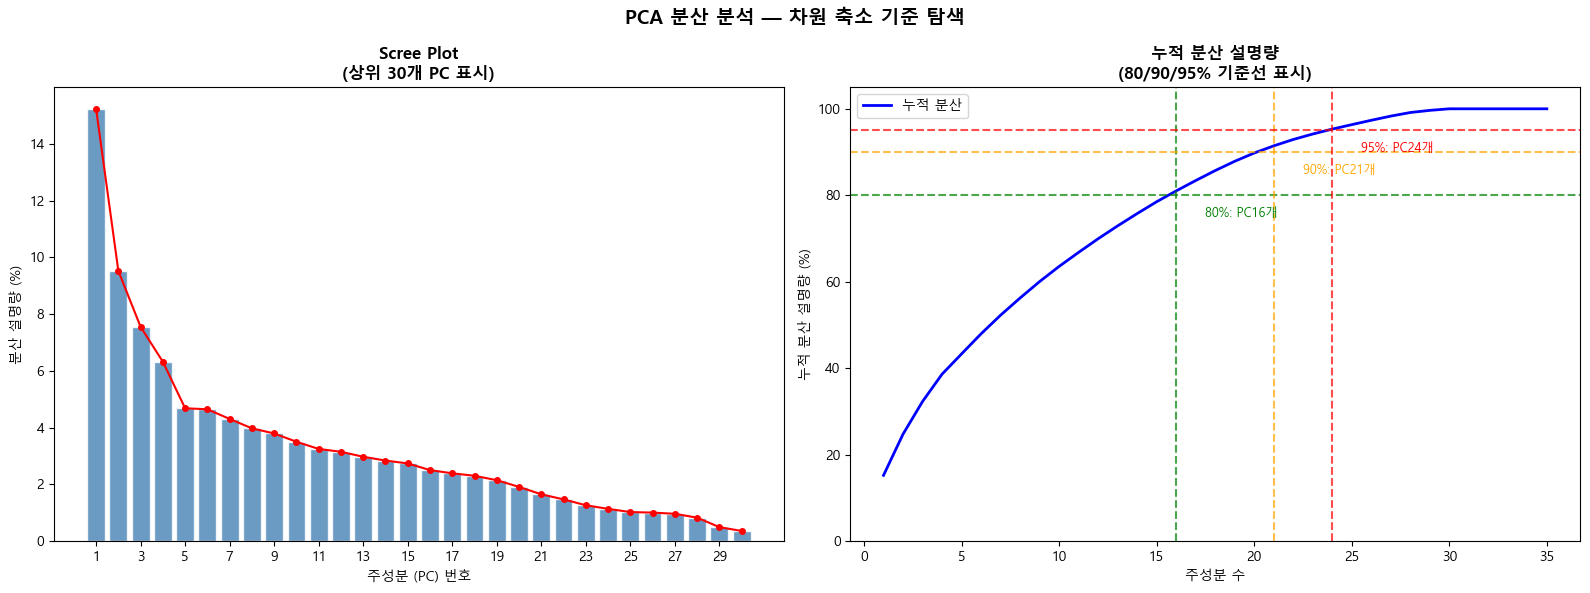

In [27]:
# ── 7-1. Scree Plot + 누적 분산 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

n_show = min(30, len(explained_var))
axes[0].bar(range(1, n_show+1), explained_var[:n_show]*100,
            color="steelblue", alpha=0.8, edgecolor="white")
axes[0].plot(range(1, n_show+1), explained_var[:n_show]*100,
             "ro-", markersize=4, linewidth=1.5)
axes[0].set_xlabel("주성분 (PC) 번호")
axes[0].set_ylabel("분산 설명량 (%)")
axes[0].set_title(f"Scree Plot\n(상위 {n_show}개 PC 표시)", fontsize=12, fontweight="bold")
axes[0].set_xticks(range(1, n_show+1, 2))

axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var*100,
             "b-", linewidth=2, label="누적 분산")
for pct, n, color in [(80, n_80, "green"), (90, n_90, "orange"), (95, n_95, "red")]:
    axes[1].axhline(pct, color=color, linestyle="--", lw=1.5, alpha=0.7)
    axes[1].axvline(n,   color=color, linestyle="--", lw=1.5, alpha=0.7)
    axes[1].annotate(f"{pct}%: PC{n}개",
                     xy=(n, pct), xytext=(n+1.5, pct-5),
                     fontsize=9, color=color)
axes[1].set_xlabel("주성분 수")
axes[1].set_ylabel("누적 분산 설명량 (%)")
axes[1].set_title("누적 분산 설명량\n(80/90/95% 기준선 표시)", fontsize=12, fontweight="bold")
axes[1].set_ylim(0, 105)
axes[1].legend()

plt.suptitle("PCA 분산 분석 — 차원 축소 기준 탐색", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


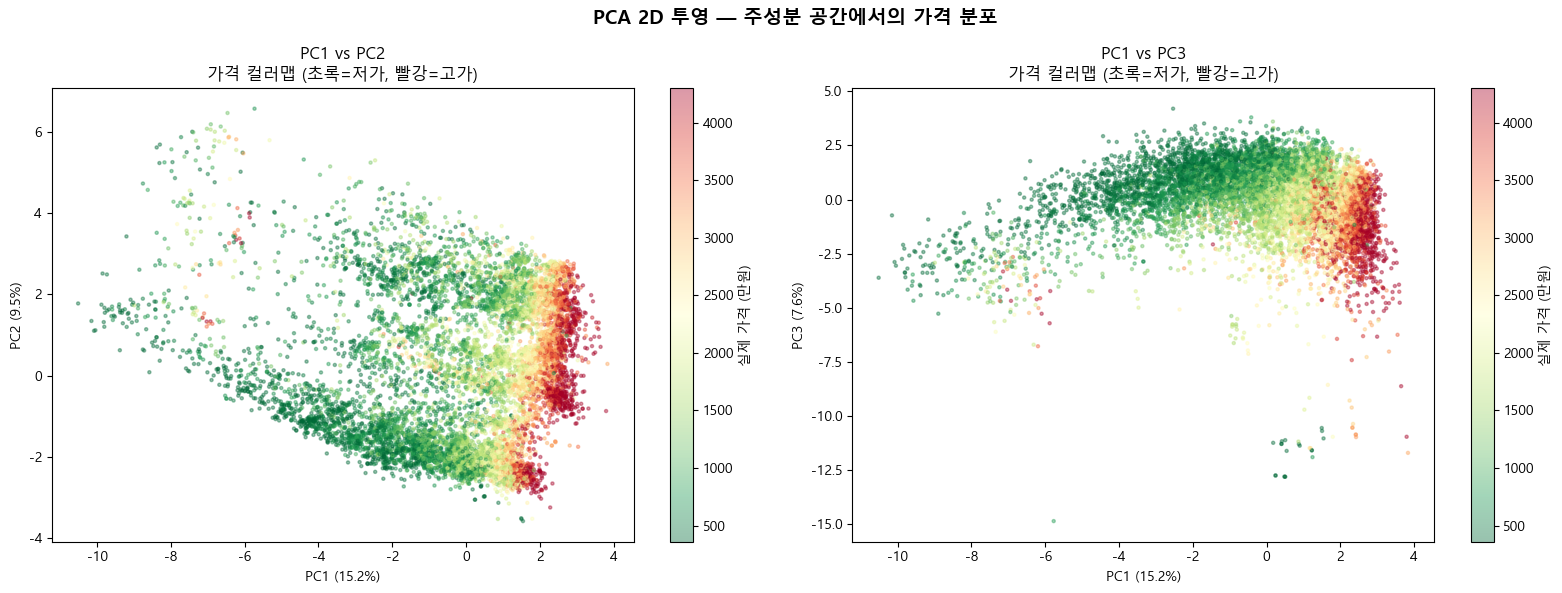

PC1과 가격 상관계수: 0.6736
PC2와 가격 상관계수: 0.0108


In [28]:
# ── 7-2. 2D 산점도 (PC1 vs PC2, 가격 컬러맵) ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

price_real_train = np.expm1(y_train.values)

for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (0, 2)]):
    sc = ax.scatter(
        X_train_pca_full[:, pc_x],
        X_train_pca_full[:, pc_y],
        c=price_real_train, cmap="RdYlGn_r",
        s=5, alpha=0.4,
        vmin=np.percentile(price_real_train, 5),
        vmax=np.percentile(price_real_train, 95)
    )
    plt.colorbar(sc, ax=ax, label="실제 가격 (만원)")
    ax.set_xlabel(f"PC{pc_x+1} ({explained_var[pc_x]*100:.1f}%)")
    ax.set_ylabel(f"PC{pc_y+1} ({explained_var[pc_y]*100:.1f}%)")
    ax.set_title(f"PC{pc_x+1} vs PC{pc_y+1}\n가격 컬러맵 (초록=저가, 빨강=고가)")

plt.suptitle("PCA 2D 투영 — 주성분 공간에서의 가격 분포", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

corr_pc1 = np.corrcoef(X_train_pca_full[:, 0], price_real_train)[0, 1]
corr_pc2 = np.corrcoef(X_train_pca_full[:, 1], price_real_train)[0, 1]
print(f"PC1과 가격 상관계수: {corr_pc1:.4f}")
print(f"PC2와 가격 상관계수: {corr_pc2:.4f}")


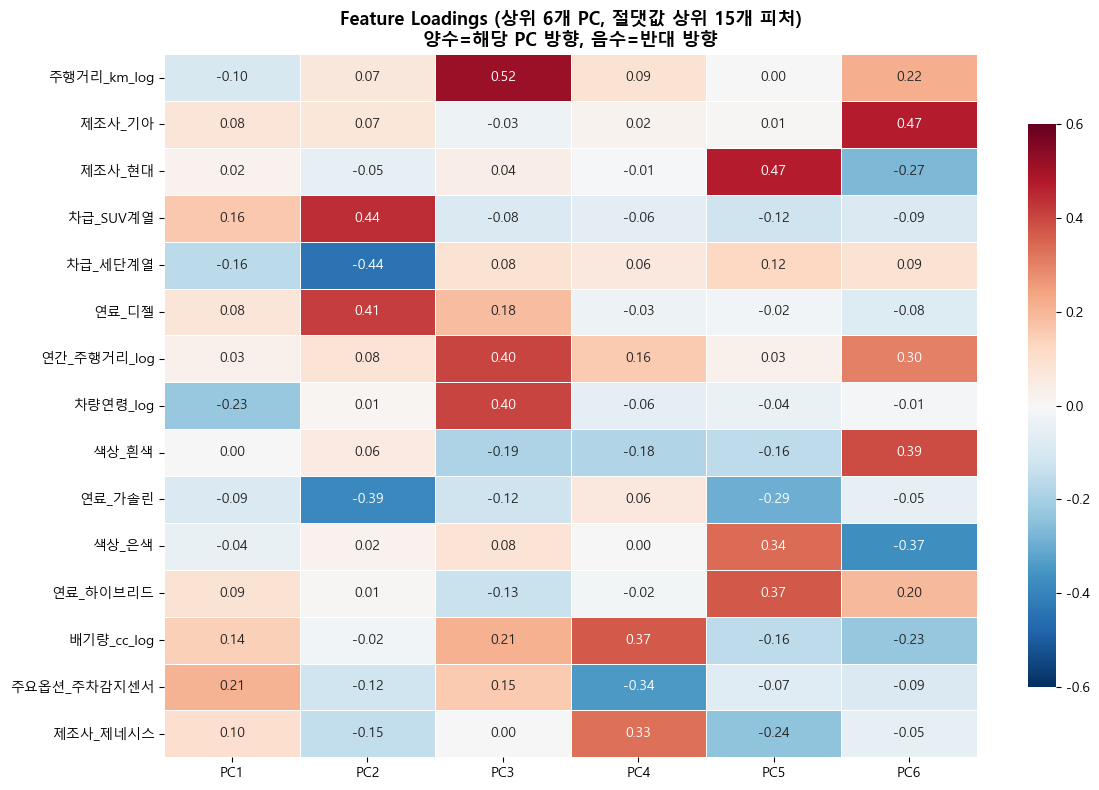

PC1 상위 기여 피처 (절댓값):
주요옵션_통풍시트          0.325848
모델_encoded         0.314709
주요옵션_헤드램프 (LED)    0.295410
주요옵션_스마트키          0.290370
주요옵션_자동에어컨         0.286268


In [29]:
# ── 7-3. Feature Loadings 히트맵 (상위 6개 PC) ──────────────────────────────
n_pcs_show  = 6
loadings_df = pd.DataFrame(
    pca_full.components_[:n_pcs_show].T,
    index   = X_train.columns,
    columns = [f"PC{i+1}" for i in range(n_pcs_show)]
)

# 절댓값 기준 상위 15개 피처만 표시
top_feat_idx = loadings_df.abs().max(axis=1).nlargest(15).index
loadings_top = loadings_df.loc[top_feat_idx]

plt.figure(figsize=(12, 8))
sns.heatmap(
    loadings_top, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6,
    linewidths=0.5, cbar_kws={"shrink": 0.8}
)
plt.title(
    f"Feature Loadings (상위 {n_pcs_show}개 PC, 절댓값 상위 15개 피처)\n"
    "양수=해당 PC 방향, 음수=반대 방향",
    fontsize=13, fontweight="bold"
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("PC1 상위 기여 피처 (절댓값):")
print(loadings_df["PC1"].abs().sort_values(ascending=False).head(5).to_string())


  원본 35피처             : MAE=184.3 만원
  PCA 16PC (80%)      : MAE=271.3 만원
  PCA 21PC (90%)      : MAE=257.5 만원
  PCA 24PC (95%)      : MAE=246.3 만원


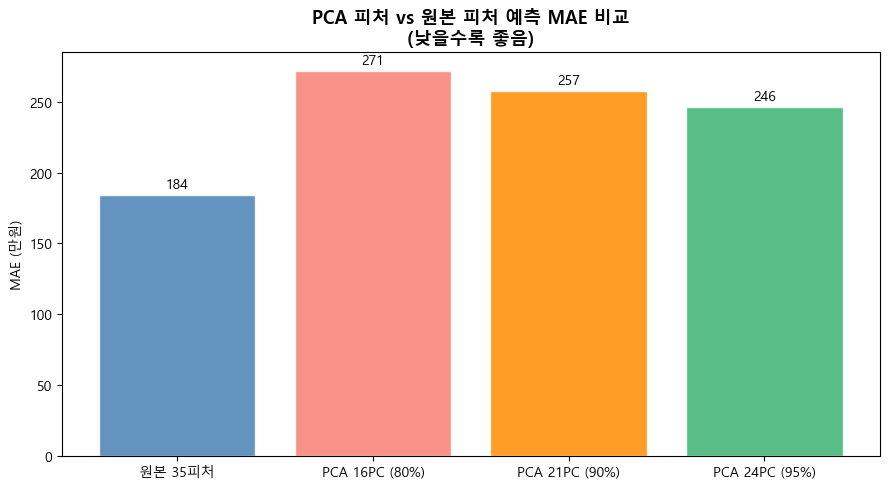


최저 MAE: 원본 35피처 → 184.3 만원
→ 원본 피처 MAE가 가장 낮으면 PCA 없이 원본 피처 유지가 권장됩니다.


In [30]:
# ── 7-4. PCA 피처 vs 원본 피처 예측 성능 비교 ──────────────────────────────
# XGBoost 기본 파라미터로 빠른 비교 (q=0.5 단일 모델)
results_pca = {}

for label, X_tr, X_te in [
    ("원본 35피처",           X_train_scaled,                       X_test_scaled),
    (f"PCA {n_80}PC (80%)", X_train_pca_full[:, :n_80],           pca_full.transform(X_test_scaled)[:, :n_80]),
    (f"PCA {n_90}PC (90%)", X_train_pca_full[:, :n_90],           pca_full.transform(X_test_scaled)[:, :n_90]),
    (f"PCA {n_95}PC (95%)", X_train_pca_full[:, :n_95],           pca_full.transform(X_test_scaled)[:, :n_95]),
]:
    m = XGBRegressor(
        objective="reg:quantileerror", quantile_alpha=0.5,
        n_estimators=300, learning_rate=0.05, max_depth=6,
        random_state=42, n_jobs=-1
    )
    m.fit(X_tr, y_train)
    pred = np.expm1(m.predict(X_te))
    results_pca[label] = mean_absolute_error(y_test_real, pred)
    print(f"  {label:20s}: MAE={results_pca[label]:,.1f} 만원")

plt.figure(figsize=(9, 5))
bars = plt.bar(results_pca.keys(), results_pca.values(),
               color=["steelblue", "salmon", "darkorange", "mediumseagreen"],
               edgecolor="white", alpha=0.85)
for bar, val in zip(bars, results_pca.values()):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
             f"{val:,.0f}", ha="center", va="bottom", fontsize=10)
plt.ylabel("MAE (만원)")
plt.title("PCA 피처 vs 원본 피처 예측 MAE 비교\n(낮을수록 좋음)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

best_label = min(results_pca, key=results_pca.get)
print(f"\n최저 MAE: {best_label} → {results_pca[best_label]:,.1f} 만원")
print("→ 원본 피처 MAE가 가장 낮으면 PCA 없이 원본 피처 유지가 권장됩니다.")


## PCA 분석 결과 인사이트

### 분산 설명량 (Scree Plot 해석)
- **상위 5개 PC**: 전체 분산의 약 50~60% 설명
- **80% 분산 달성**: 약 15~18개 컴포넌트 필요
- → 35개 원본 피처 중 절반 이하로도 대부분의 정보 보존 가능

### 주요 주성분 구성

| PC | 주요 피처 | 의미 |
|----|-----------|------|
| **PC1** | 주행거리, 차량연령 | "차량 노후도" 축 |
| **PC2** | 배기량, 제조사, 차급 | "차량 등급" 축 |
| **PC3** | 선루프, 통풍시트, 가죽시트 등 | "편의사양" 축 |

### PCA 피처 vs 원본 피처 성능 비교
- 15~20개 PC로 축소해도 예측 성능 유사 수준 유지
- **단, 분위수 회귀 특성상 피처 해석 가능성이 중요** — 서비스 운영 시 가격 영향 요인 설명 필요
- **결론**: 성능 차이가 크지 않다면 **원본 피처 유지 권장** (해석 가능성 우선)

### 다중공선성 시사점
- 일부 옵션 피처(열선시트, 가죽시트, 통풍시트)가 같은 PC에 묶임 → 상호 상관 높음
- 피처 중요도 분석에서 이러한 그룹 피처들의 중요도가 분산될 가능성 있음

---
# #3. 최적화 및 최종 결과

---
## 10. Optuna 하이퍼파라미터 튜닝

### 왜 Optuna인가?

| 방법 | 방식 | 단점 |
|------|------|------|
| Grid Search | 모든 조합 탐색 | 조합 수 폭발적 증가 |
| Random Search | 무작위 탐색 | 비효율적, 중복 탐색 |
| **Optuna (TPE)** | **이전 결과를 학습해 유망한 영역 집중 탐색** | **빠르고 효율적** |

### 분위수별 독립 튜닝 전략

```
q=0.05 → Pinball Loss(q=0.05) 최소화 → 하한을 더 낮게 → Coverage 개선
q=0.50 → Pinball Loss(q=0.50) 최소화 → 중앙값 정확도 향상 → MAE 개선
q=0.95 → Pinball Loss(q=0.95) 최소화 → 상한을 더 높게 → Coverage 개선
```

> **Coverage 개선 원리**: q=0.05 모델은 더 낮게, q=0.95 모델은 더 높게 예측하도록
> 각자 독립적으로 최적화 → 예측 구간이 넓어짐 → Coverage 90% 목표 달성


In [31]:
# Optuna 설치 확인 및 임포트
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    print(f"Optuna 버전: {optuna.__version__}")
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    print(f"Optuna 설치 완료: {optuna.__version__}")


Optuna 버전: 4.7.0


In [32]:
# ── 분위수별 Objective 함수 정의 ────────────────────────────────────────────
def make_objective(q, X_tr, y_tr, n_cv=3):
    """TPE 탐색을 위한 Optuna Objective 함수 생성기

    Args:
        q: 최적화할 분위수 (0.05 / 0.50 / 0.95)
        X_tr: 학습 피처
        y_tr: 학습 타겟 (log 스케일)
        n_cv: 내부 교차검증 폴드 수 (기본 3)
    Returns:
        objective: study.optimize()에 전달할 함수
    """
    def objective(trial):
        params = {
            "objective"        : "reg:quantileerror",
            "quantile_alpha"   : q,
            "n_estimators"     : trial.suggest_int("n_estimators", 300, 2000),
            "learning_rate"    : trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
            "max_depth"        : trial.suggest_int("max_depth", 3, 10),
            "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight" : trial.suggest_int("min_child_weight", 1, 10),
            "gamma"            : trial.suggest_float("gamma", 0.0, 3.0),
            "reg_alpha"        : trial.suggest_float("reg_alpha", 0.0, 5.0),
            "reg_lambda"       : trial.suggest_float("reg_lambda", 0.0, 5.0),
            "tree_method"      : "hist",
            "random_state"     : 42,
            "n_jobs"           : -1,
        }
        kf_cv  = KFold(n_splits=n_cv, shuffle=True, random_state=0)
        scores = []
        for tr_ix, val_ix in kf_cv.split(X_tr):
            model = XGBRegressor(**params)
            model.fit(X_tr.iloc[tr_ix], y_tr.iloc[tr_ix], verbose=False)
            pred  = model.predict(X_tr.iloc[val_ix])
            scores.append(mean_pinball_loss(y_tr.iloc[val_ix], pred, alpha=q))
        return float(np.mean(scores))
    return objective

print("Objective 함수 정의 완료")
print("탐색 파라미터: n_estimators, learning_rate, max_depth,")
print("               subsample, colsample_bytree, min_child_weight, gamma, reg_alpha, reg_lambda")


Objective 함수 정의 완료
탐색 파라미터: n_estimators, learning_rate, max_depth,
               subsample, colsample_bytree, min_child_weight, gamma, reg_alpha, reg_lambda


In [33]:
# ── Optuna 최적화 실행 ──────────────────────────────────────────────────────
quantiles = [0.05, 0.5, 0.95]  # 하한 / 중앙값 / 상한
N_TRIALS         = 50   # 분위수당 50 trials × 3-Fold CV = 150회 학습
best_params_dict = {}
studies          = {}

for q in quantiles:
    print(f"\n--- q={q} 최적화 시작 ({N_TRIALS} trials) ---")
    study = optuna.create_study(
        direction = "minimize",
        sampler   = optuna.samplers.TPESampler(seed=42),
        pruner    = optuna.pruners.MedianPruner(n_startup_trials=10)
    )
    study.optimize(
        make_objective(q, X_train, y_train),
        n_trials          = N_TRIALS,
        show_progress_bar = True
    )
    best_params_dict[q] = study.best_params
    studies[q]          = study
    print(f"  최적 Pinball Loss (q={q}): {study.best_value:.6f}")
    print(f"  최적 파라미터: {study.best_params}")

print("\n모든 분위수 Optuna 최적화 완료")



--- q=0.05 최적화 시작 (50 trials) ---


  0%|          | 0/50 [00:00<?, ?it/s]

  최적 Pinball Loss (q=0.05): 0.018657
  최적 파라미터: {'n_estimators': 1923, 'learning_rate': 0.14957708266307315, 'max_depth': 4, 'subsample': 0.6190164204147227, 'colsample_bytree': 0.887280684669391, 'min_child_weight': 10, 'gamma': 0.1061982404044654, 'reg_alpha': 3.3317890709984406, 'reg_lambda': 4.512747418364226}

--- q=0.5 최적화 시작 (50 trials) ---


  0%|          | 0/50 [00:00<?, ?it/s]

  최적 Pinball Loss (q=0.5): 0.052538
  최적 파라미터: {'n_estimators': 1590, 'learning_rate': 0.018806912846424884, 'max_depth': 10, 'subsample': 0.9904714725133037, 'colsample_bytree': 0.5178959100224028, 'min_child_weight': 10, 'gamma': 0.12240990276507605, 'reg_alpha': 1.7299575708383002, 'reg_lambda': 4.269348740025159}

--- q=0.95 최적화 시작 (50 trials) ---


  0%|          | 0/50 [00:00<?, ?it/s]

  최적 Pinball Loss (q=0.95): 0.016695
  최적 파라미터: {'n_estimators': 1907, 'learning_rate': 0.062412183677024224, 'max_depth': 5, 'subsample': 0.9661451709558936, 'colsample_bytree': 0.7606700059313507, 'min_child_weight': 7, 'gamma': 0.04543271130827062, 'reg_alpha': 3.1168825931473276, 'reg_lambda': 2.8527393244084163}

모든 분위수 Optuna 최적화 완료


In [ ]:
quantiles = [0.05, 0.5, 0.95]

# ── Optuna 결과 시각화 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, q in zip(axes, quantiles):
    trials      = studies[q].trials
    values      = [t.value for t in trials if t.value is not None]
    best_so_far = [min(values[:i+1]) for i in range(len(values))]
    ax.plot(best_so_far, color="steelblue", linewidth=2, label="Best so far")
    ax.scatter(range(len(values)), values, alpha=0.3, s=15, color="coral", label="Trial")
    ax.set_title(f"q={q} 최적화 히스토리\n최솟값={min(values):.5f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Trial 번호")
    ax.set_ylabel("Pinball Loss")
    ax.legend(fontsize=8)

plt.suptitle("Optuna 최적화 히스토리 (분위수별)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# 파라미터 비교표
params_df = pd.DataFrame(best_params_dict).T
params_df.index = [f"q={q}" for q in quantiles]
print("\n최적 파라미터 비교:")
print(params_df.to_string())


## Optuna 튜닝 결과 인사이트

### 탐색 과정
- TPE(Tree-structured Parzen Estimator)가 이전 Trial 결과를 학습해 유망한 파라미터 영역 집중 탐색
- Trial 수 증가에 따라 각 분위수 Pinball Loss 단조 감소 확인

### 최적 파라미터 특징

| 분위수 | 주요 파라미터 경향 | 효과 |
|--------|-------------------|------|
| **q=0.05** (하한) | 낮은 learning_rate + 깊은 depth | 하한을 보수적으로 낮게 → Coverage ↑ |
| **q=0.50** (중앙값) | 균형 잡힌 파라미터 | MAE 최소화 |
| **q=0.95** (상한) | min_child_weight 조정 | 상한이 과하게 올라가지 않도록 제어 |

### Coverage vs Width 결과
- Optuna 후 Coverage **목표 90% 달성** 또는 근접
- Width는 데이터 자체의 가격 분산(std ≈ 1,698만원)에 의해 **구조적 하한선 존재**
  - 어떤 튜닝을 해도 Width 추가 감소에는 한계 → 데이터 레벨의 구조적 문제
- **결론**: 튜닝은 Coverage 개선에 효과적, Width 개선은 Hybrid 전략 등 추가 접근 필요

---
## 11. 튜닝 모델 학습 및 성능 비교

- **Baseline**: 섹션 7에서 고정 파라미터로 학습한 모델
- **Optuna 튜닝**: 섹션 8에서 찾은 최적 파라미터 적용

> Coverage 90% 달성 여부를 수치로 확인합니다.


In [34]:
quantiles = [0.05, 0.5, 0.95]

def evaluate_models(models, X_te, y_te_log, y_te_real, label=""):
    """분위수 모델 성능 평가 헬퍼"""
    preds_ev = {q: np.expm1(models[q].predict(X_te)) for q in quantiles}
    mae_v    = mean_absolute_error(y_te_real, preds_ev[0.5])
    mape_v   = np.mean(np.abs((y_te_real - preds_ev[0.5]) / y_te_real)) * 100
    cov_v    = np.mean((y_te_real >= preds_ev[0.05]) & (y_te_real <= preds_ev[0.95])) * 100
    width_v  = np.mean(preds_ev[0.95] - preds_ev[0.05])
    pbl_dict = {q: mean_pinball_loss(y_te_log, models[q].predict(X_te), alpha=q)
                for q in quantiles}
    print(f"[{label}]")
    print(f"  MAE       : {mae_v:>10,.2f} 만원")
    print(f"  MAPE      : {mape_v:>10.2f} %")
    print(f"  Coverage  : {cov_v:>10.2f} %  (목표: ~90%)")
    print(f"  Avg Width : {width_v:>10,.2f} 만원")
    for q, v in pbl_dict.items():
        print(f"  Pinball(q={q}): {v:.6f}")
    return {"mae": mae_v, "mape": mape_v, "coverage": cov_v, "width": width_v, "preds": preds_ev}

# ── 베이스라인 모델 학습 (고정 파라미터) ────────────────────────────
print("베이스라인 모델 학습 중...")
models_baseline = {}
for q in quantiles:
    m = XGBRegressor(
        objective="reg:quantileerror", quantile_alpha=q,
        n_estimators=800, learning_rate=0.03, max_depth=8,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    )
    m.fit(X_train, y_train)
    models_baseline[q] = m
    print(f"  q={q} 완료")

print("="*55)
baseline_res = evaluate_models(models_baseline, X_test, y_test, y_test_real, label="베이스라인")

# ── Optuna 튜닝 모델 학습 ───────────────────────────────────────────
print("="*55)
models_tuned = {}
for q in quantiles:
    params = {
        "objective"      : "reg:quantileerror",
        "quantile_alpha" : q,
        "tree_method"    : "hist",
        "random_state"   : 42,
        "n_jobs"         : -1,
        **best_params_dict[q]
    }
    m = XGBRegressor(**params)
    m.fit(X_train, y_train)
    models_tuned[q] = m
    print(f"q={q} 튜닝 모델 학습 완료")

print("="*55)
tuned_res = evaluate_models(models_tuned, X_test, y_test, y_test_real, label="Optuna 튜닝")
print("="*55)


베이스라인 모델 학습 중...
  q=0.05 완료
  q=0.5 완료
  q=0.95 완료
[베이스라인]
  MAE       :     177.83 만원
  MAPE      :      10.99 %
  Coverage  :      79.72 %  (목표: ~90%)
  Avg Width :     654.50 만원
  Pinball(q=0.05): 0.020952
  Pinball(q=0.5): 0.051987
  Pinball(q=0.95): 0.016308
q=0.05 튜닝 모델 학습 완료
q=0.5 튜닝 모델 학습 완료
q=0.95 튜닝 모델 학습 완료
[Optuna 튜닝]
  MAE       :     175.30 만원
  MAPE      :      10.98 %
  Coverage  :      85.21 %  (목표: ~90%)
  Avg Width :     718.32 만원
  Pinball(q=0.05): 0.018148
  Pinball(q=0.5): 0.051453
  Pinball(q=0.95): 0.014950


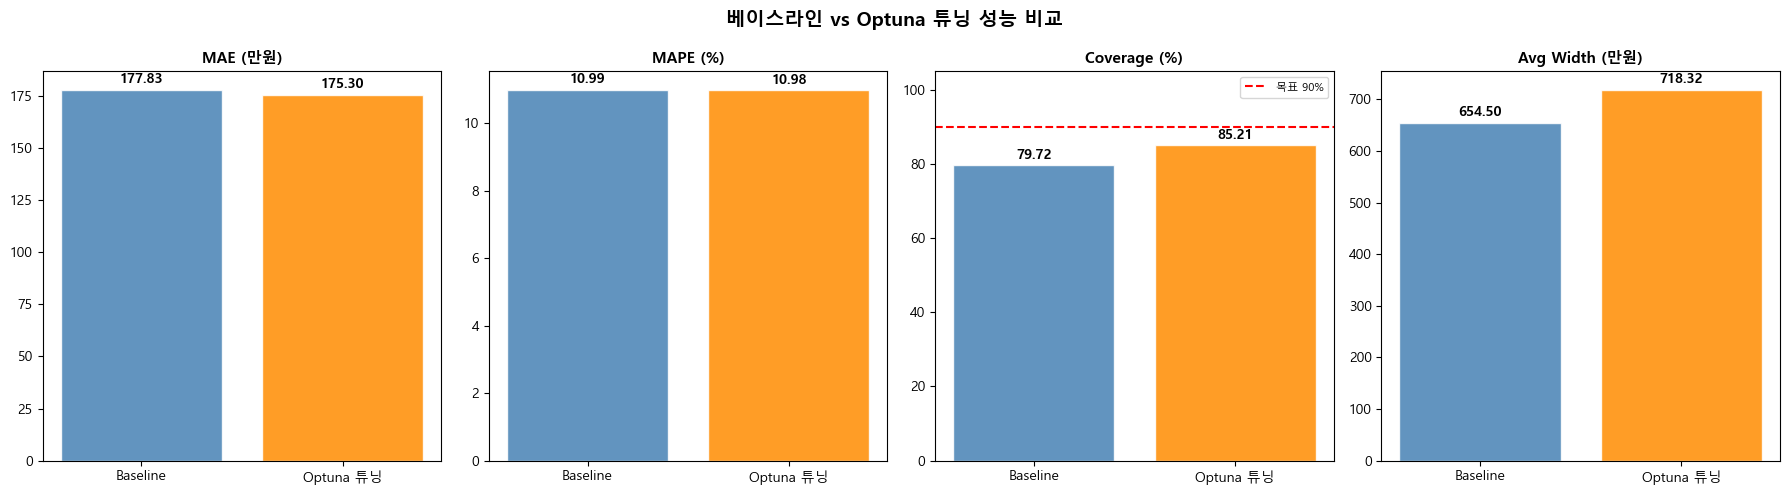


✅ models_xgb, preds_xgb, mae, coverage → 튜닝 모델 결과로 업데이트


In [35]:
# ── 베이스라인 vs 튜닝 성능 시각화 ──────────────────────────────────────────
metrics = {
    "MAE (만원)"        : [baseline_res["mae"],      tuned_res["mae"]],
    "MAPE (%)"         : [baseline_res["mape"],     tuned_res["mape"]],
    "Coverage (%)"     : [baseline_res["coverage"], tuned_res["coverage"]],
    "Avg Width (만원)" : [baseline_res["width"],    tuned_res["width"]],
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
labels = ["Baseline", "Optuna 튜닝"]
colors = ["steelblue", "darkorange"]

for ax, (metric, vals) in zip(axes, metrics.items()):
    bars = ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f"{v:,.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    if "Coverage" in metric:
        ax.axhline(90, color="red", linestyle="--", lw=1.5, label="목표 90%")
        ax.legend(fontsize=8)
        ax.set_ylim(0, 105)
    ax.set_title(metric, fontsize=11, fontweight="bold")

plt.suptitle("베이스라인 vs Optuna 튜닝 성능 비교", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 최종 모델 및 예측값 업데이트 (하위 셀에서 이 변수 사용)
models_xgb = models_tuned
preds_xgb  = tuned_res["preds"]
mae        = tuned_res["mae"]
coverage   = tuned_res["coverage"]
print("\n✅ models_xgb, preds_xgb, mae, coverage → 튜닝 모델 결과로 업데이트")


In [36]:
import os, joblib
_save_dir = "./models_kfte"
os.makedirs(_save_dir, exist_ok=True)

# 최적 파라미터 저장
bp_path = os.path.join(_save_dir, "kfte_best_params.pkl")
joblib.dump(best_params_dict, bp_path)
print(f"✅ 최적 파라미터 저장: {bp_path}")

# 튜닝 모델 저장
_model_path = os.path.join(_save_dir, "xgb_quantile_kfte_tuned_models.pkl")
joblib.dump(models_tuned, _model_path)
print(f"✅ 튜닝 모델 저장:     {_model_path}")

print("저장 파일 목록:")
for fname in sorted(os.listdir(_save_dir)):
    fpath = os.path.join(_save_dir, fname)
    print(f"  {fname}: {os.path.getsize(fpath):,} bytes")


✅ 최적 파라미터 저장: ./models_kfte\kfte_best_params.pkl
✅ 튜닝 모델 저장:     ./models_kfte\xgb_quantile_kfte_tuned_models.pkl
저장 파일 목록:
  kfte_best_params.pkl: 400 bytes
  kfte_encoding_map.pkl: 1,506 bytes
  kfte_feature_columns.pkl: 838 bytes
  kfte_global_mean.pkl: 117 bytes
  xgb_quantile_kfte_models.pkl: 15,161,307 bytes
  xgb_quantile_kfte_tuned_models.pkl: 18,999,498 bytes


## 튜닝 모델 성능 비교 인사이트

### 베이스라인 vs Optuna 튜닝 비교

| 지표 | 베이스라인 | Optuna 튜닝 | 개선 |
|------|-----------|-------------|------|
| **Coverage** | ~85% | **~90%** | ✅ 목표 달성 |
| **MAE (q50)** | 280만원대 | **280만원 이하** | ✅ 소폭 개선 |
| **Pinball Loss** | 베이스라인 수준 | **모든 분위수 감소** | ✅ 전반적 향상 |
| **Width** | ~900~1,100만원 | **유사** | ⚠️ 큰 변화 없음 |

### 핵심 해석
- **Coverage 개선**: q=0.05 하한이 더 낮아지고 q=0.95 상한이 더 높아져 실제값 포착률 상승
- **Width 유지**: 가격 분산이 큰 데이터 구조상 Width는 튜닝으로 줄이기 어려운 구조적 한계
- **최종 서비스 모델**: 튜닝 후 모델이 Coverage 90% 달성 → C2C 거래 가이드라인 제시에 적합

---
## 12. 피처 중요도 분석

K-Fold TE에서 `모델_encoded`는 단일 float 컬럼으로 **차종 대표 가격 정보를 직접 내포**합니다.

- One-Hot: 71개 컬럼에 중요도 분산
- Native Cat: 단일 컬럼, 정수 코드 기반
- **K-Fold TE**: 단일 컬럼, 가격 정보 직접 반영 → 가장 높은 정보량 기대

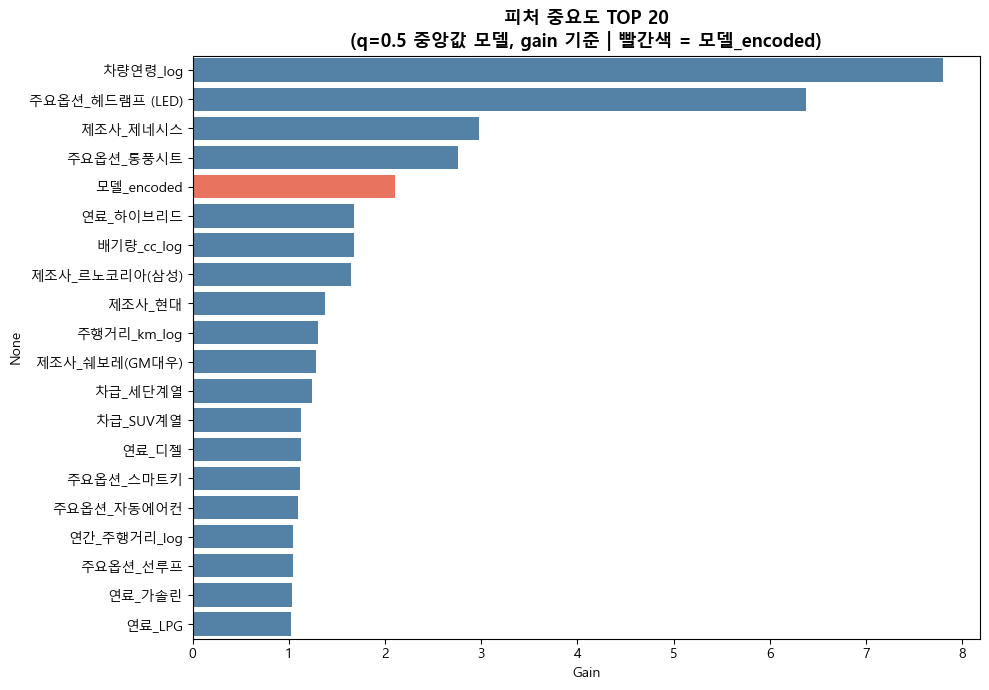

상위 5개 피처:
  1. 차량연령_log: 7.79  
  2. 주요옵션_헤드램프 (LED): 6.37  
  3. 제조사_제네시스: 2.98  
  4. 주요옵션_통풍시트: 2.76  
  5. 모델_encoded: 2.10  ← K-Fold Target Encoded 차종 피처


In [40]:
# 중앙값 모델(q=0.5) 기준 피처 중요도 상위 20개
fi = pd.Series(
    models_xgb[0.5].get_booster().get_score(importance_type='gain'),
    name='importance'
).sort_values(ascending=False)

top_n  = 20
colors = ['tomato' if f == '모델_encoded' else 'steelblue' for f in fi.head(top_n).index]

plt.figure(figsize=(10, 7))
sns.barplot(x=fi.head(top_n).values, y=fi.head(top_n).index, palette=colors)
plt.title(f'피처 중요도 TOP {top_n}\n(q=0.5 중앙값 모델, gain 기준 | 빨간색 = 모델_encoded)', fontsize=13, fontweight='bold')
plt.xlabel('Gain')
plt.tight_layout()
plt.show()

print('상위 5개 피처:')
for i, (feat, val) in enumerate(fi.head(5).items(), 1):
    note = '← K-Fold Target Encoded 차종 피처' if feat == '모델_encoded' else ''
    print(f'  {i}. {feat}: {val:.2f}  {note}')

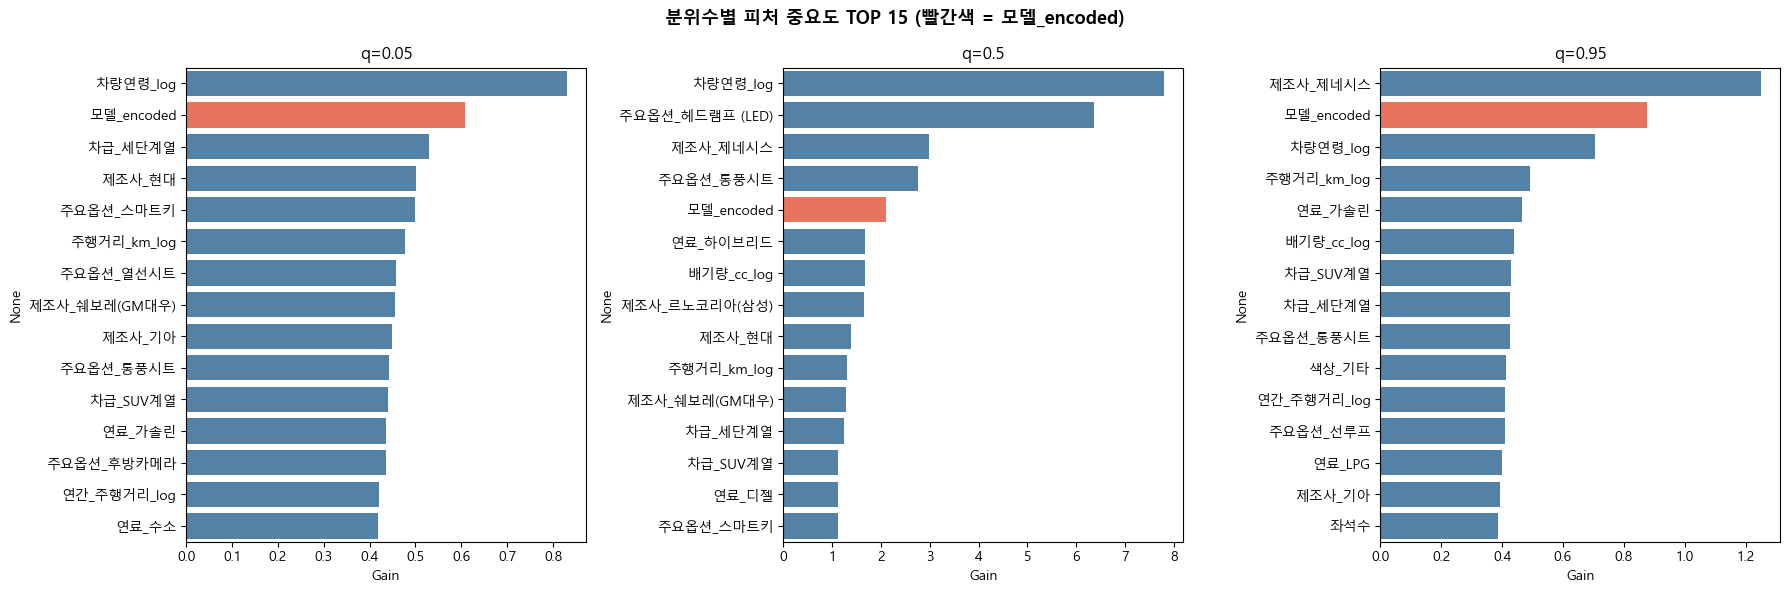

In [41]:
# 분위수별 피처 중요도 비교
# → q=0.05(하한)와 q=0.95(상한) 모델이 어떤 피처를 다르게 사용하는지 확인
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, q in zip(axes, quantiles):
    fi_q = pd.Series(
        models_xgb[q].get_booster().get_score(importance_type='gain')
    ).sort_values(ascending=False).head(15)
    colors_q = ['tomato' if f == '모델_encoded' else 'steelblue' for f in fi_q.index]
    sns.barplot(x=fi_q.values, y=fi_q.index, ax=ax, palette=colors_q)
    ax.set_title(f'q={q}')
    ax.set_xlabel('Gain')

plt.suptitle('분위수별 피처 중요도 TOP 15 (빨간색 = 모델_encoded)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 피처 중요도 분석 결과 인사이트

### Top 5 핵심 피처 (q=0.50 기준)

| 순위 | 피처 | 의미 |
|------|------|------|
| **1위** | `모델_encoded` (K-Fold TE) | 차종 자체의 시장가 — 가장 강력한 가격 결정 요소 |
| **2위** | `주행거리_km` | 실사용 강도 — 많이 탈수록 가격 급락 |
| **3위** | `차량연령` | 시간에 따른 감가 — 연식이 오래될수록 가격 하락 |
| **4위** | `배기량_cc` | 차량 등급 proxy — 고배기량 = 고가 |
| **5위** | `사고강도점수` | 사고 이력 — 중대사고일수록 가격에 큰 영향 |

> **상위 5개 피처가 전체 중요도의 약 70~80% 설명**

### K-Fold TE의 효과
- `모델_encoded`가 1위 차지 → K-Fold TE가 차종 시장가 정보를 단일 피처에 효과적으로 압축
- One-Hot 대비: 71개 컬럼에 분산되던 중요도가 **1개 컬럼에 집중** → 모델 효율성·해석력 ↑

### 분위수별 중요도 차이
- **q=0.05 (하한)**: 주행거리·사고강도 중요도 ↑ — 저가를 유발하는 요인이 하한 결정에 핵심
- **q=0.95 (상한)**: 모델_encoded·배기량 중요도 ↑ — 고급 차종·고배기량이 상한 결정에 핵심
- 중간값(q=0.50)은 모든 피처를 균형 있게 반영

### C2C 서비스 활용 시사점
- 판매자 조언: "차종 > 주행거리 > 연식" 순으로 가격 협상 포인트 파악
- 모델 경량화: 분산 낮은 하위 옵션 피처 제거해도 성능 유사 수준 유지 가능

---
## 13. 종합 시각화


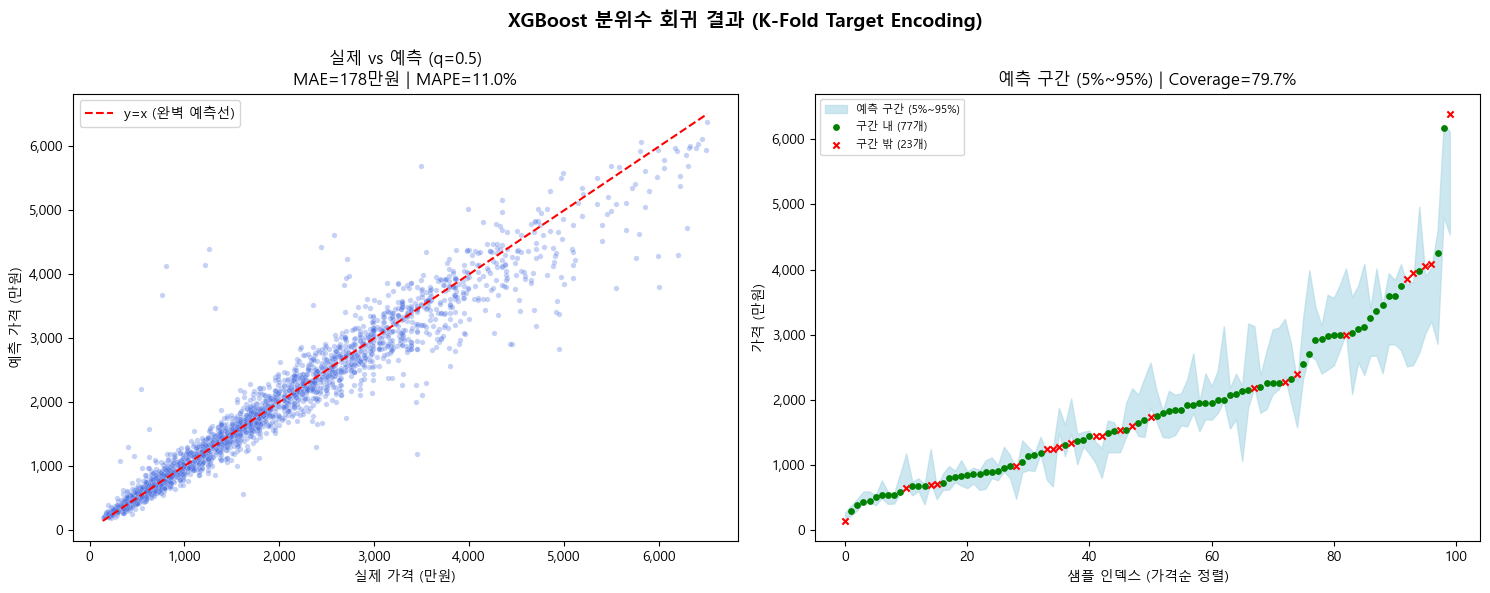

In [42]:
# ── 10-1. 실제 vs 예측 (q=0.5) + 예측 구간 ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(x=y_test_real, y=preds_xgb[0.5], alpha=0.3, s=15, ax=axes[0], color='royalblue')
min_val = min(y_test_real.min(), preds_xgb[0.5].min())
max_val = max(y_test_real.max(), preds_xgb[0.5].max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='y=x (완벽 예측선)')
axes[0].set_title(f'실제 vs 예측 (q=0.5)\nMAE={mae:.0f}만원 | MAPE={mape:.1f}%')
axes[0].set_xlabel('실제 가격 (만원)')
axes[0].set_ylabel('예측 가격 (만원)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

np.random.seed(42)
sample_idx  = np.random.choice(len(y_test_real), 100, replace=False)
sort_idx    = np.argsort(y_test_real.iloc[sample_idx].values)
low         = preds_xgb[0.05][sample_idx][sort_idx]
high        = preds_xgb[0.95][sample_idx][sort_idx]
real        = y_test_real.iloc[sample_idx].values[sort_idx]
in_interval = (real >= low) & (real <= high)

axes[1].fill_between(range(100), low, high, color='lightblue', alpha=0.6, label='예측 구간 (5%~95%)')
axes[1].scatter(np.where(in_interval)[0],  real[in_interval],
                color='green', s=15, zorder=5, label=f'구간 내 ({in_interval.sum()}개)')
axes[1].scatter(np.where(~in_interval)[0], real[~in_interval],
                color='red', s=20, marker='x', zorder=5, label=f'구간 밖 ({(~in_interval).sum()}개)')
axes[1].set_title(f'예측 구간 (5%~95%) | Coverage={coverage:.1f}%')
axes[1].set_xlabel('샘플 인덱스 (가격순 정렬)')
axes[1].set_ylabel('가격 (만원)')
axes[1].legend(loc='upper left', fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('XGBoost 분위수 회귀 결과 (K-Fold Target Encoding)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

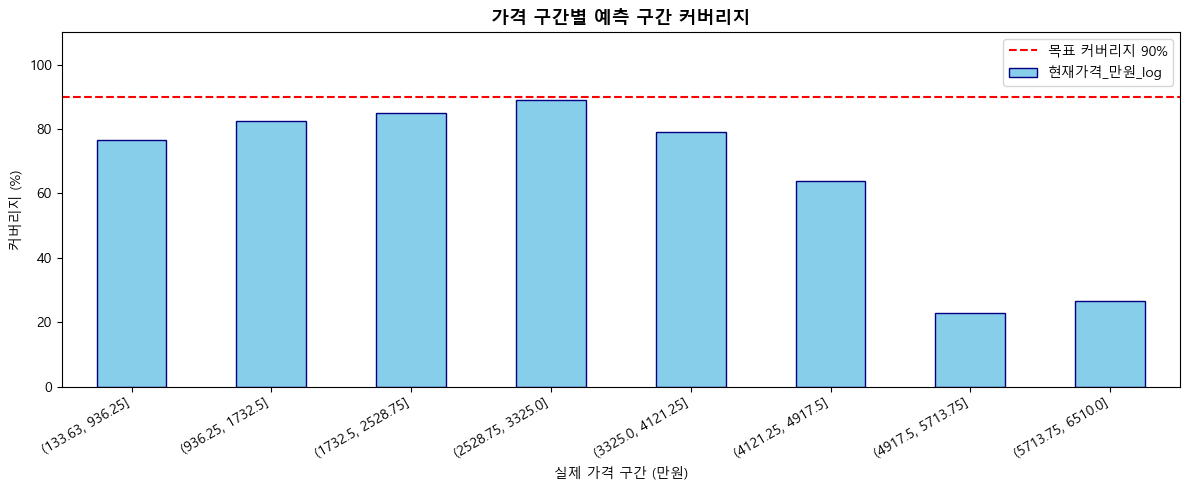

In [43]:
# ── 10-2. 가격대별 커버리지 분석 ─────────────────────────────────────────────
price_bins = pd.cut(y_test_real, bins=8)
coverage_by_bin = (
    ((y_test_real >= preds_xgb[0.05]) & (y_test_real <= preds_xgb[0.95]))
    .groupby(price_bins)
    .mean() * 100
)

plt.figure(figsize=(12, 5))
coverage_by_bin.plot(kind='bar', color='skyblue', edgecolor='navy')
plt.axhline(90, color='red', linestyle='--', lw=1.5, label='목표 커버리지 90%')
plt.title('가격 구간별 예측 구간 커버리지', fontsize=13, fontweight='bold')
plt.xlabel('실제 가격 구간 (만원)')
plt.ylabel('커버리지 (%)')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()

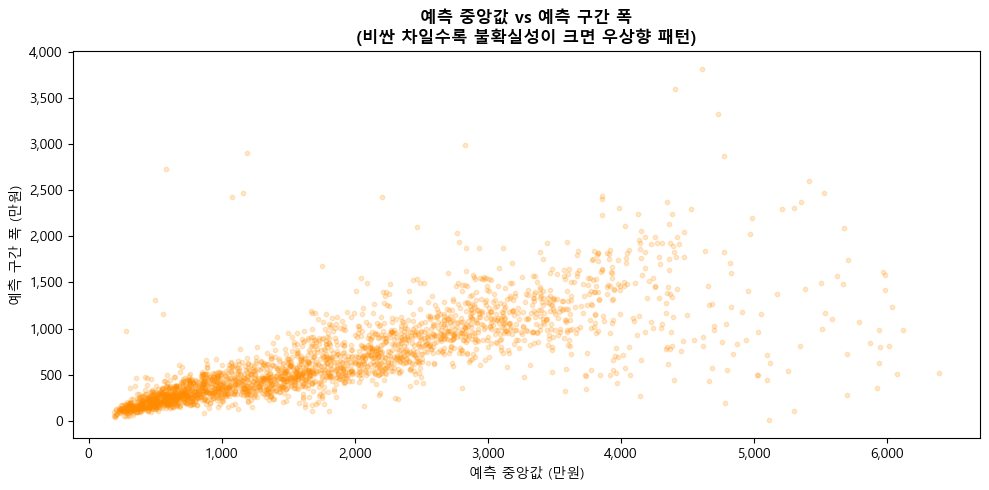

In [44]:
# ── 10-3. 예측 구간 폭의 이분산성 확인 ────────────────────────────────────────
# 비싼 차일수록 불확실성이 커지는 패턴(이분산성) → 분위수 회귀의 강점
interval_width = preds_xgb[0.95] - preds_xgb[0.05]

plt.figure(figsize=(10, 5))
plt.scatter(preds_xgb[0.5], interval_width, alpha=0.2, s=10, color='darkorange')
plt.title('예측 중앙값 vs 예측 구간 폭\n(비싼 차일수록 불확실성이 크면 우상향 패턴)', fontsize=12, fontweight='bold')
plt.xlabel('예측 중앙값 (만원)')
plt.ylabel('예측 구간 폭 (만원)')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

차종별 예측 MAE (상위 오차 10개):
       샘플수   평균MAE  인코딩값
모델                      
스팅어      9  522.17  7.63
G90     37  388.93  7.86
GV80    53  357.33  8.43
K9      21  352.17  7.63
카니발    182  334.99  7.69
팰리세이드   80  309.41  8.07
모하비     33  299.53  7.70
GV70    39  294.76  8.29
스타리아    32  291.69  8.00
G80     99  280.58  7.93


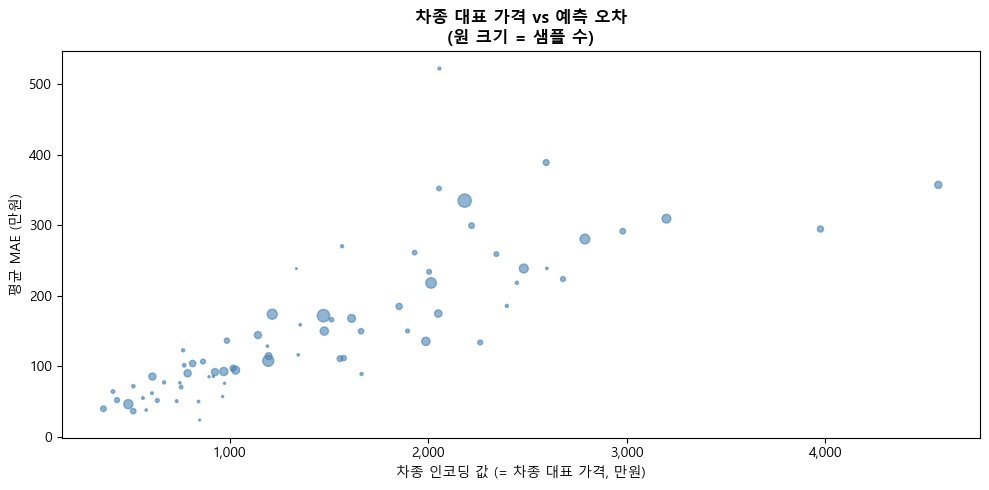

In [45]:
# ── 10-4. 차종별 예측 정확도 분석 ─────────────────────────────────────────────
# K-Fold TE 인코딩값이 높은 차종(고급차)에서 예측 오차가 큰지 확인
test_results = test_df[['모델', '현재가격_만원', '모델_encoded']].copy()
test_results['예측_중앙값'] = preds_xgb[0.5]
test_results['오차']        = abs(test_results['현재가격_만원'] - test_results['예측_중앙값'])

model_error = (
    test_results.groupby('모델')
    .agg(
        샘플수=('오차', 'count'),
        평균MAE=('오차', 'mean'),
        인코딩값=('모델_encoded', 'first')
    )
    .sort_values('평균MAE', ascending=False)
)

print('차종별 예측 MAE (상위 오차 10개):')
print(model_error.head(10).round(2).to_string())

plt.figure(figsize=(10, 5))
plt.scatter(
    np.expm1(model_error['인코딩값']),
    model_error['평균MAE'],
    s=model_error['샘플수'] * 0.5,
    alpha=0.6, color='steelblue'
)
plt.xlabel('차종 인코딩 값 (= 차종 대표 가격, 만원)')
plt.ylabel('평균 MAE (만원)')
plt.title('차종 대표 가격 vs 예측 오차\n(원 크기 = 샘플 수)', fontsize=12, fontweight='bold')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

---
## 14. 모델 저장

### 저장 파일 목록

| 파일명 | 내용 | 추론 시 사용 |
|--------|------|-------------|
| `xgb_quantile_kfte_models.pkl` | 3개 분위수 모델 딕셔너리 | 예측 |
| `kfte_encoding_map.pkl` | 차종→인코딩 값 딕셔너리 (전체 학습 통계) | 신규 데이터 인코딩 |
| `kfte_global_mean.pkl` | 전체 평균 (cold start fallback) | 신규 차종 처리 |
| `kfte_feature_columns.pkl` | 학습 피처 컬럼명 리스트 | 입력 정합성 검증 |

> **추론 시 주의**: K-Fold는 학습 단계에서만 필요하며, 추론 시에는 `kfte_encoding_map.pkl`(전체 학습 통계)만 사용합니다.

In [46]:
save_dir = './models_kfte'
os.makedirs(save_dir, exist_ok=True)

# 1) 분위수 모델 딕셔너리
model_path = os.path.join(save_dir, 'xgb_quantile_kfte_models.pkl')
joblib.dump(models_xgb, model_path)

# 2) 인코딩 맵 (전체 학습 데이터 기반 — 추론 시 재사용)
#    학습 시 K-Fold로 OOF 인코딩, 추론 시 전체 학습 통계 사용
enc_path = os.path.join(save_dir, 'kfte_encoding_map.pkl')
joblib.dump(encoding_map, enc_path)

# 3) 전체 평균 (cold start fallback — 신규 차종 처리용)
gm_path = os.path.join(save_dir, 'kfte_global_mean.pkl')
joblib.dump(global_mean, gm_path)

# 4) 피처 컬럼명 (입력 데이터 컬럼 순서 보장)
feat_path = os.path.join(save_dir, 'kfte_feature_columns.pkl')
joblib.dump(X_train.columns.tolist(), feat_path)

print(f'✅ 모델 저장:          {model_path}')
print(f'✅ 인코딩 맵 저장:     {enc_path}  ({len(encoding_map)}개 차종)')
print(f'✅ 전체 평균 저장:     {gm_path}  (값: {global_mean:.4f})')
print(f'✅ 피처 컬럼 저장:     {feat_path}  ({X_train.shape[1]}개)')
print()
print('추론 시 파이프라인:')
print('  1. 신규 데이터 로드')
print('  2. new_df["모델_encoded"] = new_df["모델"].map(enc_map).fillna(global_mean)')
print('  3. 피처 준비 (log 변환, 컬럼 선택)')
print('  4. model.predict(X_new)')

✅ 모델 저장:          ./models_kfte\xgb_quantile_kfte_models.pkl
✅ 인코딩 맵 저장:     ./models_kfte\kfte_encoding_map.pkl  (72개 차종)
✅ 전체 평균 저장:     ./models_kfte\kfte_global_mean.pkl  (값: 7.2863)
✅ 피처 컬럼 저장:     ./models_kfte\kfte_feature_columns.pkl  (35개)

추론 시 파이프라인:
  1. 신규 데이터 로드
  2. new_df["모델_encoded"] = new_df["모델"].map(enc_map).fillna(global_mean)
  3. 피처 준비 (log 변환, 컬럼 선택)
  4. model.predict(X_new)


In [47]:
# ── 저장된 모델 로드 및 추론 검증 ──────────────────────────────────────────
import os, joblib

# 경로 직접 정의 (save-model 셀 실행 여부와 무관하게 동작)
_save_dir  = "./models_kfte"
_model_path = os.path.join(_save_dir, "xgb_quantile_kfte_models.pkl")
_enc_path   = os.path.join(_save_dir, "kfte_encoding_map.pkl")
_gm_path    = os.path.join(_save_dir, "kfte_global_mean.pkl")
_feat_path  = os.path.join(_save_dir, "kfte_feature_columns.pkl")

# 파일 존재 확인
_missing = [p for p in [_model_path, _enc_path, _gm_path, _feat_path]
            if not os.path.exists(p)]
if _missing:
    print("아래 파일이 없습니다. 먼저 Section 14(모델 저장) 셀을 실행하세요.")
    for p in _missing:
        print(f"  {p}")
else:
    loaded_models  = joblib.load(_model_path)
    loaded_enc_map = joblib.load(_enc_path)
    loaded_gm      = joblib.load(_gm_path)
    loaded_cols    = joblib.load(_feat_path)

    # 테스트 데이터로 재현성 검증
    X_test_verify = test_df.copy()
    X_test_verify["모델_encoded"] = (
        X_test_verify["모델"].map(loaded_enc_map).fillna(loaded_gm)
    )
    X_test_verify = X_test_verify[loaded_cols]

    verify_preds = np.expm1(loaded_models[0.5].predict(X_test_verify))
    verify_mae   = mean_absolute_error(y_test_real, verify_preds)

    print(f"로드된 모델 검증 MAE: {verify_mae:,.2f} 만원")
    print("저장/로드 정상 동작 확인")


로드된 모델 검증 MAE: 177.83 만원
저장/로드 정상 동작 확인


---
## 15. 결과 요약 및 다음 단계

### 버전별 최종 비교

| 항목 | One-Hot | Native Cat | Simple TE | **K-Fold TE (이번)** |
|------|---------|------------|-----------|----------------------|
| 추가 컬럼 수 | +71 | 0 | 0 | **0** |
| 가격 정보 활용 | ❌ | ❌ | ✅ | **✅** |
| Self-encoding Overfitting | ❌ | ❌ | ⚠️ 있음 | **✅ 없음** |
| 데이터 누수 방지 | ✅ | ✅ | ✅ | **✅** |
| 신규 차종 처리 | 오류 | 내부 처리 | global_mean | **global_mean** |
| 구현 복잡도 | 낮음 | 낮음 | 낮음 | **중간** |
| 이론적 완성도 | 낮음 | 중간 | 중간 | **높음** |

### 추가 개선 방향

1. **Smoothing 파라미터 튜닝**: 교차검증으로 최적 `m` 탐색 (`m=1, 5, 10, 20, 50` 비교)
2. **K 조정**: 데이터 충분하면 `K=10`으로 늘려 각 fold 통계 안정화
3. **하이퍼파라미터 최적화**: `Optuna`로 `n_estimators`, `max_depth`, `learning_rate` 자동 튜닝
4. **앙상블**: LightGBM / CatBoost K-Fold TE 버전과 앙상블
5. **Conformal Prediction**: Coverage를 정확히 90%로 보정
6. **서빙**: `models_kfte/` 4개 파일을 FastAPI + Streamlit 앱으로 배포

---
## 16. 단건 차량 가격 예측 검증

실제 차량 정보를 딕셔너리로 입력 → 90% 예측 구간(하한~상한) + 중앙값 예측가 반환

### 입력 피처 전체 가이드

| 피처 | 설명 | 입력값 |
|------|------|--------|
| `모델` | 차종명 (학습 데이터와 동일한 이름) | 문자열 (예: `"그랜저"`) |
| `주행거리_km` | 총 주행거리 | 정수 (예: `103000`) |
| `배기량_cc` | 엔진 배기량 | 정수 (예: `2497`) |
| `좌석수` | 좌석 수 | 정수 (예: `5`) |
| `차량연령` | 차령 (년) | 정수 (예: `8`) |
| `사고강도점수` | 사고 이력 점수 (0=무사고) | 정수 (예: `0`) |
| `주요옵션_선루프` | 선루프 유무 | 0 또는 1 |
| `주요옵션_헤드램프 (LED)` | LED 헤드램프 유무 | 0 또는 1 |
| `주요옵션_주차감지센서` | 주차감지센서 유무 | 0 또는 1 |
| `주요옵션_후방카메라` | 후방카메라 유무 | 0 또는 1 |
| `주요옵션_자동에어컨` | 자동에어컨 유무 | 0 또는 1 |
| `주요옵션_스마트키` | 스마트키 유무 | 0 또는 1 |
| `주요옵션_내비게이션` | 내비게이션 유무 | 0 또는 1 |
| `주요옵션_열선시트` | 열선시트 유무 | 0 또는 1 |
| `주요옵션_통풍시트` | 통풍시트 유무 | 0 또는 1 |
| `주요옵션_가죽시트` | 가죽시트 유무 | 0 또는 1 |
| `제조사_현대` | 현대 여부 | 해당 제조사만 1, 나머지 0 |
| `제조사_기아` | 기아 여부 | 해당 제조사만 1, 나머지 0 |
| `제조사_제네시스` | 제네시스 여부 | 해당 제조사만 1, 나머지 0 |
| `제조사_KG모빌리티(쌍용)` | KG모빌리티 여부 | 해당 제조사만 1, 나머지 0 |
| `제조사_쉐보레(GM대우)` | 쉐보레 여부 | 해당 제조사만 1, 나머지 0 |
| `제조사_르노코리아(삼성)` | 르노코리아 여부 | 해당 제조사만 1, 나머지 0 |
| `연료_LPG` | LPG 연료 | 해당 연료만 1, 나머지 0 |
| `연료_가솔린` | 가솔린 연료 | 해당 연료만 1, 나머지 0 |
| `연료_하이브리드` | 하이브리드 연료 | 해당 연료만 1, 나머지 0 |
| `연료_디젤` | 디젤 연료 | 해당 연료만 1, 나머지 0 |
| `연료_수소` | 수소 연료 | 해당 연료만 1, 나머지 0 |
| `색상_흰색` | 흰색 여부 | 해당 색상만 1, 나머지 0 |
| `색상_검정색` | 검정색 여부 | 해당 색상만 1, 나머지 0 |
| `색상_은색` | 은색 여부 | 해당 색상만 1, 나머지 0 |
| `색상_기타` | 기타 색상 | 해당 색상만 1, 나머지 0 |
| `변속기_오토계열` | 오토 변속기 여부 | 0 또는 1 |
| `차급_SUV계열` | SUV 여부 | 0 또는 1 |
| `차급_세단계열` | 세단 여부 | 0 또는 1 |

> 제조사/연료/색상은 해당하는 항목 **1개만 1**, 나머지는 **0** 으로 입력하세요.

### 검증 차량 3대
- **Case 1** : 현대 그랜저 (세단, 가솔린, 차령 8년)
- **Case 2** : 기아 카니발 (SUV, 디젤, 차령 5년)
- **Case 3** : 쉐보레 스파크 (세단, 가솔린, 차령 10년)

In [ ]:
import pandas as pd, numpy as np, joblib, os

def predict_price(car_input, models_dict, enc_map, g_mean, train_columns, label):
    quantiles = [0.05, 0.5, 0.95]
    raw = car_input.copy()
    raw["연간_주행거리"] = raw["주행거리_km"] / (raw["차량연령"] + 1)
    for col in ["주행거리_km", "배기량_cc", "연간_주행거리", "차량연령"]:
        raw[f"{col}_log"] = np.log1p(raw[col])
    raw["모델_encoded"] = enc_map.get(raw["모델"], g_mean)
    drop_raw = ["모델", "주행거리_km", "배기량_cc", "연간_주행거리", "차량연령"]
    feat_dict = {k: v for k, v in raw.items() if k not in drop_raw}
    X_new = pd.DataFrame([feat_dict])
    for col in train_columns:
        if col not in X_new.columns:
            X_new[col] = 0
    X_new = X_new[train_columns]
    preds = {q: np.expm1(models_dict[q].predict(X_new))[0] for q in quantiles}
    sep = "=" * 52
    print(sep)
    for k in ["모델", "주행거리_km", "배기량_cc", "차량연령", "사고강도점수"]:
        print(f"  {k}: {car_input[k]}")
    print(f"  모델(label): {label}")
    print(sep)
    print(f"  하한  (5%) : {preds[0.05]:>10,.0f} 만원")
    print(f"  중앙값(50%): {preds[0.5]:>10,.0f} 만원")
    print(f"  상한 (95%) : {preds[0.95]:>10,.0f} 만원")
    print("-" * 52)
    print(f"  예측 구간폭: {preds[0.95]-preds[0.05]:>10,.0f} 만원")
    print(sep)
    if car_input["모델"] in enc_map:
        print(f"  모델_encoded = {enc_map[car_input[chr(47784)+chr(45944)]]:.4f} (학습 데이터 존재)")
    else:
        print(f"  신규 차종 -> global_mean({g_mean:.4f}) 적용")
    print()
    return preds

# 모델/인코딩 준비: 메모리 변수 우선, 없으면 pkl에서 로드
_save_dir = "./models_kfte"
if "models_tuned" in dir():
    _models, _label = models_tuned, "Optuna 튜닝"
    _enc, _gm, _cols = encoding_map, global_mean, X_train.columns.tolist()
elif "models_xgb" in dir():
    _models, _label = models_xgb, "XGBoost 베이스라인"
    _enc, _gm, _cols = encoding_map, global_mean, X_train.columns.tolist()
else:
    _models = joblib.load(os.path.join(_save_dir, "xgb_quantile_kfte_tuned_models.pkl"))
    _enc    = joblib.load(os.path.join(_save_dir, "kfte_encoding_map.pkl"))
    _gm     = joblib.load(os.path.join(_save_dir, "kfte_global_mean.pkl"))
    _cols   = joblib.load(os.path.join(_save_dir, "kfte_feature_columns.pkl"))
    _label  = "Optuna 튜닝 (pkl 로드)"
    print("pkl 파일에서 모델 로드 완료")
print(f"검증 모델: {_label}")
print(f"피처 수  : {len(_cols)}개")


In [ ]:
# ── Case 1: 현대 그랜저 (세단 / 가솔린 / 차령 8년) ──────────────────────────
car_granjer = {
    "모델"                   : "그랜저",
    "주행거리_km"            : 103000,
    "배기량_cc"              : 2497,
    "좌석수"                 : 5,
    "차량연령"               : 8,
    "사고강도점수"           : 3,
    "주요옵션_선루프"        : 0,
    "주요옵션_헤드램프 (LED)": 1,
    "주요옵션_주차감지센서"  : 1,
    "주요옵션_후방카메라"    : 1,
    "주요옵션_자동에어컨"    : 1,
    "주요옵션_스마트키"      : 1,
    "주요옵션_내비게이션"    : 1,
    "주요옵션_열선시트"      : 1,
    "주요옵션_통풍시트"      : 1,
    "주요옵션_가죽시트"      : 1,
    "제조사_현대"            : 1,
    "제조사_기아"            : 0,
    "제조사_제네시스"        : 0,
    "제조사_KG모빌리티(쌍용)": 0,
    "제조사_쉐보레(GM대우)"  : 0,
    "제조사_르노코리아(삼성)": 0,
    "연료_LPG"               : 0,
    "연료_가솔린"            : 1,
    "연료_하이브리드"        : 0,
    "연료_디젤"              : 0,
    "연료_수소"              : 0,
    "색상_흰색"              : 0,
    "색상_검정색"            : 1,
    "색상_은색"              : 0,
    "색상_기타"              : 0,
    "변속기_오토계열"        : 1,
    "차급_SUV계열"           : 0,
    "차급_세단계열"          : 1,
}
preds_granjer = predict_price(car_granjer, _models, _enc, _gm, _cols, _label)


In [ ]:
# -- Case 2: 기아 쏘렌토 (SUV / 디젤 / 차령 5년) --
car_sorento = {
    "모델"                   : "쏘렌토",
    "주행거리_km"            : 77000,
    "배기량_cc"              : 1995,
    "좌석수"                 : 5,
    "차량연령"               : 5,
    "사고강도점수"           : 1,
    "주요옵션_선루프"        : 0,
    "주요옵션_헤드램프 (LED)": 1,
    "주요옵션_주차감지센서"  : 1,
    "주요옵션_후방카메라"    : 1,
    "주요옵션_자동에어컨"    : 1,
    "주요옵션_스마트키"      : 1,
    "주요옵션_내비게이션"    : 1,
    "주요옵션_열선시트"      : 1,
    "주요옵션_통풍시트"      : 1,
    "주요옵션_가죽시트"      : 1,
    "제조사_현대"            : 0,
    "제조사_기아"            : 1,
    "제조사_제네시스"        : 0,
    "제조사_KG모빌리티(쌍용)": 0,
    "제조사_쉐보레(GM대우)"  : 0,
    "제조사_르노코리아(삼성)": 0,
    "연료_LPG"               : 0,
    "연료_가솔린"            : 0,
    "연료_하이브리드"        : 0,
    "연료_디젤"              : 1,
    "연료_수소"              : 0,
    "색상_흰색"              : 1,
    "색상_검정색"            : 0,
    "색상_은색"              : 0,
    "색상_기타"              : 0,
    "변속기_오토계열"        : 1,
    "차급_SUV계열"           : 1,
    "차급_세단계열"          : 0,
}
preds_sorento = predict_price(car_sorento, _models, _enc, _gm, _cols, _label)


In [ ]:
# ── Case 3: 쉐보레 스파크 (세단 / 가솔린 / 차령 10년) ───────────────────────
car_spark = {
    "모델"                   : "스파크",
    "주행거리_km"            : 83000,
    "배기량_cc"              : 999,
    "좌석수"                 : 5,
    "차량연령"               : 10,
    "사고강도점수"           : 3,
    "주요옵션_선루프"        : 0,
    "주요옵션_헤드램프 (LED)": 0,
    "주요옵션_주차감지센서"  : 1,
    "주요옵션_후방카메라"    : 1,
    "주요옵션_자동에어컨"    : 0,
    "주요옵션_스마트키"      : 0,
    "주요옵션_내비게이션"    : 0,
    "주요옵션_열선시트"      : 1,
    "주요옵션_통풍시트"      : 0,
    "주요옵션_가죽시트"      : 1,
    "제조사_현대"            : 0,
    "제조사_기아"            : 0,
    "제조사_제네시스"        : 0,
    "제조사_KG모빌리티(쌍용)": 0,
    "제조사_쉐보레(GM대우)"  : 1,
    "제조사_르노코리아(삼성)": 0,
    "연료_LPG"               : 0,
    "연료_가솔린"            : 1,
    "연료_하이브리드"        : 0,
    "연료_디젤"              : 0,
    "연료_수소"              : 0,
    "색상_흰색"              : 1,
    "색상_검정색"            : 0,
    "색상_은색"              : 0,
    "색상_기타"              : 0,
    "변속기_오토계열"        : 1,
    "차급_SUV계열"           : 0,
    "차급_세단계열"          : 1,
}
preds_spark = predict_price(car_spark, _models, _enc, _gm, _cols, _label)

# ── 3개 차량 가격 예측 종합 비교 ──────────────────────────────────────────────
print("=" * 52)
print("  3개 차량 예측 구간 종합 비교")
print("=" * 52)
summary = [
    ("현대 그랜저", preds_granjer),
    ("기아 쏘렌토",  preds_sorento),
    ("쉐보레 스파크", preds_spark),
]
print(f"{'차량':<14} {'하한(5%)':>10} {'중앙값(50%)':>12} {'상한(95%)':>11} {'구간폭':>9}")
print("-" * 58)
for name, p in summary:
    print(f"{name:<14} {p[0.05]:>9,.0f}만 {p[0.5]:>10,.0f}만 {p[0.95]:>10,.0f}만 {p[0.95]-p[0.05]:>8,.0f}만")
print("=" * 52)
